# **Movie Memory Experiment**

**Authors:** Arkadipta Das, Rohan Karmakar, Mahima Chakraborty



In [ ]:
# Installing necessary packages (will take some time)
# install.packages("openxlsx")
# install.packages("effsize")
# install.packages("rstatix")
# install.packages('coin')

In [ ]:
# necessary libraries
library(ggplot2)
library(readr)
library(dplyr)
library(readxl)
library(tidyverse)
library(openxlsx)
library(stats)
library(effsize)
library(effectsize)
library(rstatix)
library(coin)
library(lsr)
library(emmeans)
library(tidyr)
library(ggcorrplot)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'openxlsx' was built under R version 4.5.3"
Warning message:
"package 'effsize' was built under R version 4.5.3"
Warning message:
"package 'effectsize' was built under R version 4.5.3"
Warning message:
"package 'rstatix' was built under R version 4.5.3"

Attaching package: 'rstatix'


The following objects are 

### Data extraction from files and cleaning

In [ ]:
zip_file_path <- "./BRSM data csv.zip"
extraction_path <- "./BRSM data csv"

# Unzip the file
unzip(zip_file_path, exdir = extraction_path)

print(paste("File '", zip_file_path, "' unzipped to '", extraction_path, "'", sep = ""))

[1] "File './BRSM data csv.zip' unzipped to './BRSM data csv'"


In [ ]:
path = "./BRSM data csv/BRSM data csv/BRSM data csv"
all_files = list.files(path, pattern = "*.csv", full.names = TRUE)
head(all_files)

[1] "./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv"
[2] "./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv"
[3] "./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv"
[4] "./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv"
[5] "./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv"
[6] "./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv"

In [ ]:
abrupt_files <- grep("AB", all_files, value = TRUE)
natural_files <- grep("NB", all_files, value = TRUE)
print(paste("Abrupt subjects:", length(abrupt_files)))
print(paste("Natural subjects:", length(natural_files)))

[1] "Abrupt subjects: 81"
[1] "Natural subjects: 90"


In [ ]:
combined_files <- c(abrupt_files, natural_files)
length(combined_files)

[1] 171

In [ ]:
head(combined_files)

[1] "./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv"
[2] "./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv"
[3] "./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv"
[4] "./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv"
[5] "./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv"
[6] "./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv"

In [ ]:
abrupt <- read.csv("./BRSM data csv/BRSM data csv/abruptmovies.csv")
head(abrupt)

,path,duration,is_repeat
,<chr>,<int>,<int>
1,abrupt_videos\abrupt_1.mp4,17,0
2,abrupt_videos\abrupt_2.mp4,31,0
3,abrupt_videos\abrupt_3.mp4,27,1
4,abrupt_videos\abrupt_3.mp4,27,1
5,abrupt_videos\abrupt_4.mp4,32,0
6,abrupt_videos\abrupt_5.mp4,33,0


In [ ]:
natural <- read.csv("./BRSM data csv/BRSM data csv/naturalmovies.csv")
head(natural)

,path,duration,is_repeat
,<chr>,<int>,<int>
1,Trimmed_videos/natural_1.mp4,19,0
2,Trimmed_videos/natural_2.mp4,31,0
3,Trimmed_videos/natural_3.mp4,28,1
4,Trimmed_videos/natural_3.mp4,28,1
5,Trimmed_videos/natural_4.mp4,31,0
6,Trimmed_videos/natural_5.mp4,33,0


In [ ]:
targets_lures <- read.csv("./BRSM data csv/BRSM data csv/target_and_lures.csv")
head(targets_lures)

,movie_id,target_img,lure_img
,<int>,<chr>,<chr>
1,1,frames\Vid1_EM_T.png,frames\Vid1_L.png
2,2,frames\Vid2_BB_T.png,frames\Vid2_L.png
3,3,frames\Vid3_BB_T.png,frames\Vid3_L.png
4,4,frames\Vid4_EM_T.png,frames\Vid4_L.png
5,5,frames\Vid5_EM_T.png,frames\Vid5_L.png
6,6,frames\Vid6_BB_T.png,frames\Vid6_L.png


In [ ]:
em_count <- sum(grepl("EM", targets_lures$target_img))

# Count how many filenames contain "BB"
bb_count <- sum(grepl("BB", targets_lures$target_img))

# Print results
cat("Number of targets with 'EM':", em_count, "\n")
cat("Number of targets with 'BB':", bb_count, "\n")

Number of targets with 'EM': 20 
Number of targets with 'BB': 20 


In [ ]:
# Demographic data
demo_data <- as.data.frame(read_excel("./BRSM data csv/BRSM data csv/Demographic data.xlsx"))

In [ ]:
head(demo_data)

,Sub ID,Age,Gender,Handedness,Vision
,<chr>,<dbl>,<chr>,<chr>,<chr>
1,sub34_AB,22,Female,Right handed,Corrected to normal
2,sub23_AB,21,Female,Right handed,Normal
3,sub46_NB,20,Female,Right handed,Corrected to normal
4,sub72_NB,28,Male,Right handed,Corrected to normal
5,sub150_NB,27,Male,Right handed,Normal
6,sub162_NB,23,Male,Right handed,Normal


In [ ]:
length(demo_data$`Sub ID`)

[1] 185

In [ ]:
# Get subjects for which data has been provided
subjects <- str_extract(combined_files, "[Ss]ub\\d+_[A-Z]+")
sort(subjects)

[1] "sub100_AB" "sub101_AB" "sub102_AB" "sub103_AB" "sub104_AB" "sub105_AB"
  [7] "sub106_AB" "sub107_AB" "sub108_AB" "sub109_AB" "sub110_AB" "sub111_AB"
 [13] "sub112_AB" "sub113_AB" "sub114_AB" "sub115_AB" "sub116_AB" "sub117_AB"
 [19] "sub118_AB" "sub119_AB" "sub120_AB" "sub121_AB" "sub122_AB" "sub123_AB"
 [25] "sub124_AB" "sub125_AB" "sub126_AB" "sub127_AB" "sub128_AB" "sub129_AB"
 [31] "sub130_AB" "sub131_AB" "sub132_AB" "sub133_AB" "sub134_AB" "sub135_AB"
 [37] "sub136_AB" "sub137_AB" "sub138_AB" "sub139_AB" "sub14_NB"  "sub140_AB"
 [43] "sub141_AB" "sub142_AB" "sub143_AB" "sub144_AB" "sub145_AB" "sub146_AB"
 [49] "sub147_AB" "sub148_AB" "sub149_AB" "sub15_NB"  "sub150_NB" "sub151_NB"
 [55] "sub152_NB" "sub153_NB" "sub154_NB" "sub155_NB" "sub156_NB" "sub157_AB"
 [61] "sub158_NB" "sub159_NB" "sub16_NB"  "sub160_NB" "sub161_NB" "sub162_NB"
 [67] "sub163_NB" "sub164_NB" "sub165_NB" "sub166_NB" "sub167_NB" "sub168_NB"
 [73] "sub169_NB" "sub17_NB"  "sub170_NB" "sub171_NB" "sub172_NB" "sub173_NB"
 [79] "sub174_NB" "sub175_NB" "sub176_NB" "sub177_NB" "sub178_NB" "sub179_NB"
 [85] "sub18_NB"  "sub180_NB" "sub181_NB" "sub182_NB" "sub183_NB" "sub184_NB"
 [91] "sub185_NB" "sub19_NB"  "sub21_NB"  "sub22_NB"  "sub23_AB"  "sub24_NB" 
 [97] "sub25_AB"  "sub26_AB"  "sub27_AB"  "sub28_AB"  "sub29_AB"  "sub30_AB" 
[103] "sub31_AB"  "sub32_AB"  "sub33_AB"  "sub34_AB"  "sub35_AB"  "sub36_AB" 
[109] "sub37_AB"  "sub38_AB"  "sub39_AB"  "sub40_AB"  "Sub41_AB"  "sub42_NB" 
[115] "Sub43_NB"  "sub44_NB"  "sub45_NB"  "sub46_NB"  "sub47_NB"  "sub48_NB" 
[121] "sub49_NB"  "sub50_NB"  "sub51_NB"  "sub52_NB"  "sub53_NB"  "sub54_NB" 
[127] "sub55_NB"  "sub56_NB"  "sub57_NB"  "sub58_NB"  "sub59_NB"  "sub60_NB" 
[133] "sub61_NB"  "sub62_NB"  "sub63_NB"  "sub64_NB"  "sub65_NB"  "sub66_NB" 
[139] "sub67_NB"  "sub68_NB"  "sub69_NB"  "sub70_NB"  "sub71_NB"  "sub72_NB" 
[145] "sub73_NB"  "sub74_NB"  "sub75_NB"  "sub76_NB"  "sub77_NB"  "sub78_NB" 
[151] "sub79_NB"  "sub80_NB"  "sub81_NB"  "sub82_NB"  "sub83_NB"  "sub84_NB" 
[157] "sub85_NB"  "sub86_NB"  "sub87_NB"  "sub88_AB"  "sub89_AB"  "sub90_AB" 
[163] "sub91_AB"  "sub92_AB"  "sub93_AB"  "sub94_AB"  "sub95_AB"  "sub96_AB" 
[169] "sub97_AB"  "sub98_AB"  "sub99_AB"

In [ ]:
demo_data_filtered <- demo_data %>%
  filter(`Sub ID` %in% subjects)
length(demo_data_filtered$`Sub ID`)

[1] 165

6 subjects present in analysis files are missing from the demographics spreadsheet.

In [ ]:
table(demo_data_filtered$Gender)


Female   Male 
    44    104 

In [ ]:
any(is.na(demo_data_filtered))

[1] TRUE

In [ ]:
sum(!complete.cases(demo_data_filtered))

[1] 17

In [ ]:
# incomplete demo data
demo_data_filtered[!complete.cases(demo_data_filtered),]

,Sub ID,Age,Gender,Handedness,Vision
,<chr>,<dbl>,<chr>,<chr>,<chr>
13,sub49_NB,NA,NA,NA,NA
22,sub175_NB,NA,NA,NA,NA
23,sub80_NB,NA,NA,NA,NA
29,sub66_NB,NA,NA,NA,NA
30,sub39_AB,NA,NA,NA,NA
43,sub19_NB,NA,NA,NA,NA
53,sub117_AB,NA,NA,NA,NA
88,sub146_AB,NA,NA,NA,NA
100,sub178_NB,NA,NA,NA,NA


In [ ]:
# replace NA with mean age, mode for gender, handedness and vision
demo_data_filtered$Age[is.na(demo_data_filtered$Age)] <- mean(demo_data_filtered$Age, na.rm = TRUE)
demo_data_filtered$Gender[is.na(demo_data_filtered$Gender)] <- names(table(demo_data_filtered$Gender))[which.max(table(demo_data_filtered$Gender))]
demo_data_filtered$Handedness[is.na(demo_data_filtered$Handedness)] <- names(table(demo_data_filtered$Handedness))[which.max(table(demo_data_filtered$Handedness))]
demo_data_filtered$Vision[is.na(demo_data_filtered$Vision)] <- names(table(demo_data_filtered$Vision))[which.max(table(demo_data_filtered$Vision))]

In [ ]:
any(!complete.cases(demo_data_filtered))

[1] FALSE

In [ ]:
nrow(demo_data_filtered)

[1] 165

In [ ]:
# list 6 subjects missing in demo data
missing_subjects <- setdiff(subjects, demo_data_filtered$`Sub ID`)
print("Subjects missing in demo data:")
print(missing_subjects)

[1] "Subjects missing in demo data:"
[1] "sub157_AB" "sub38_AB"  "Sub41_AB"  "Sub43_NB"  "sub86_NB"  "sub87_NB" 


In [ ]:
# add demo data for the 6 subjects missing in the same manner
gender_mode <- names(table(demo_data_filtered$Gender))[which.max(table(demo_data_filtered$Gender))]
handedness_mode <- names(table(demo_data_filtered$Handedness))[which.max(table(demo_data_filtered$Handedness))]
vision_mode <- names(table(demo_data_filtered$Vision))[which.max(table(demo_data_filtered$Vision))]
demo_data_filtered <- rbind(demo_data_filtered, data.frame(`Sub ID` = missing_subjects,
                                                            Age = mean(demo_data_filtered$Age, na.rm = TRUE),
                                                            Gender = gender_mode,
                                                            Handedness = handedness_mode,
                                                            Vision = vision_mode,
                                                            check.names = FALSE))


In [ ]:
nrow(demo_data_filtered)

[1] 171

In [ ]:
summary(demo_data_filtered$Age)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  19.00   21.00   22.24   22.24   23.00   28.00 

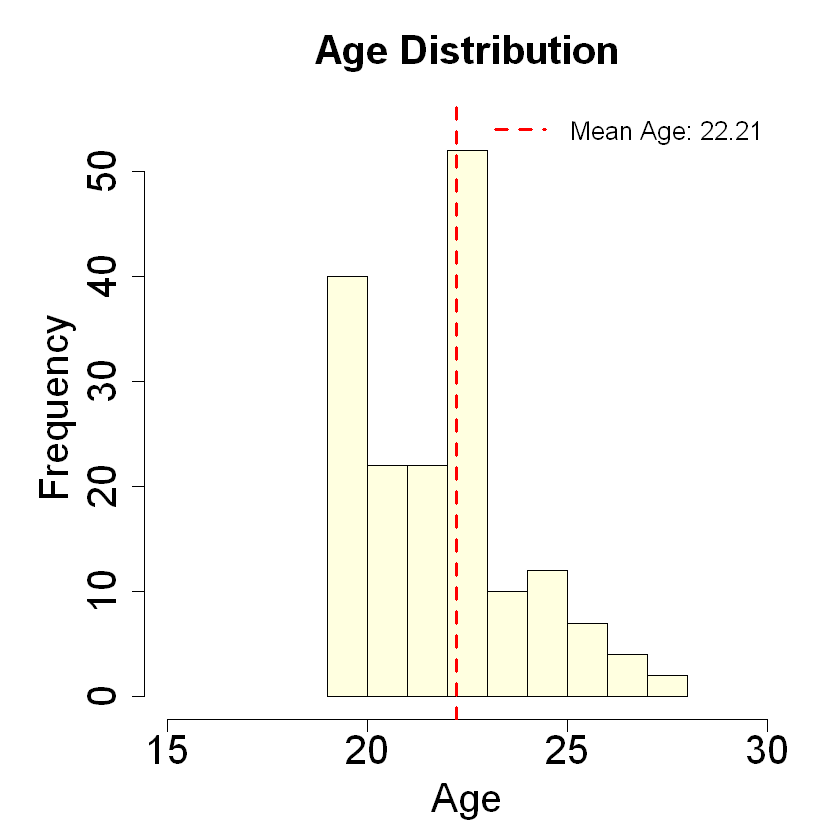

In [ ]:
par(mar = c(5, 6, 4, 2))
hist(demo_data_filtered$Age,
     main = "Age Distribution",
     xlab = "Age",
     ylab = "Frequency",
     col = "lightyellow",
     border = "black",
     xlim = c(15, 30),
     ylim = c(0, 55),
     cex.axis = 2,
     cex.lab = 2,
     cex.main = 2.0)
abline(v = 22.21, col = "red", lwd = 3, lty = 2)
legend("topright", legend = paste("Mean Age:", round(22.21, 2)),
       col = "red", lwd = 3, lty = 2, bty = "n", cex = 1.3)

In [ ]:
table(demo_data_filtered$Handedness)


 Left Handed Right handed 
           8          163 

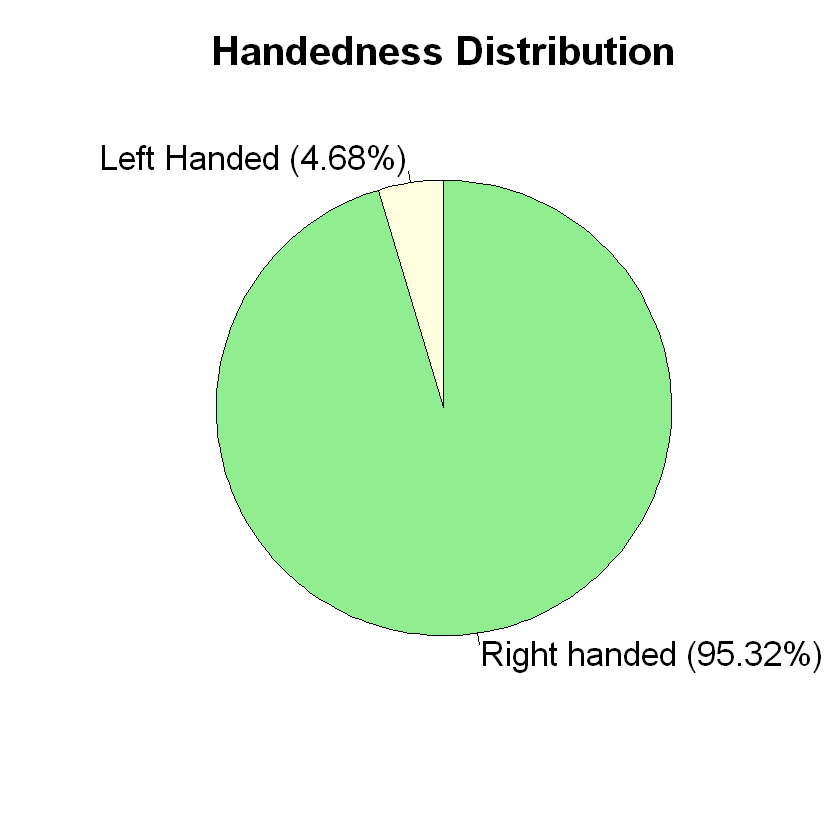

In [ ]:
# Distribution of handedness

handedness_counts <- as.data.frame(table(demo_data_filtered$Handedness))
colnames(handedness_counts) <- c("Handedness", "Count")
handedness_counts$Percent <- round((handedness_counts$Count / sum(handedness_counts$Count)) * 100, 2)
# pie chart

pie(handedness_counts$Percent,
    labels = paste(handedness_counts$Handedness, " (", handedness_counts$Percent, "%)", sep = ""),
    main = "Handedness Distribution",
    col = c("lightyellow", "lightgreen"),
    init.angle = 90,
    cex.main = 2.0,
        cex.axis = 4,
        cex = 1.7

    )

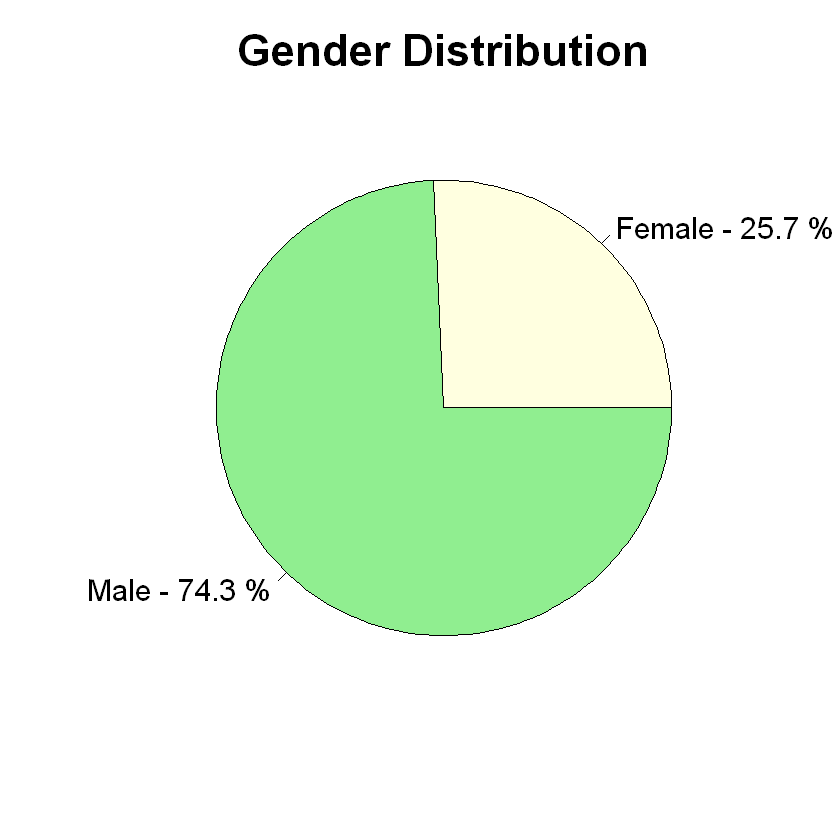

In [ ]:
# Gender distribution
gender_counts <- as.data.frame(table(demo_data_filtered$Gender))
colnames(gender_counts) <- c("Gender","Count")
gender_counts$Percent <- round((gender_counts$Count / sum(gender_counts$Count)) * 100, 2)

pie(gender_counts$Percent,
    labels = paste(gender_counts$Gender, "-", round(gender_counts$Percent,1), "%"),
    main = "Gender Distribution",
    col = c("lightyellow", "lightgreen"),
    cex.main = 2.2,
    cex = 1.5)

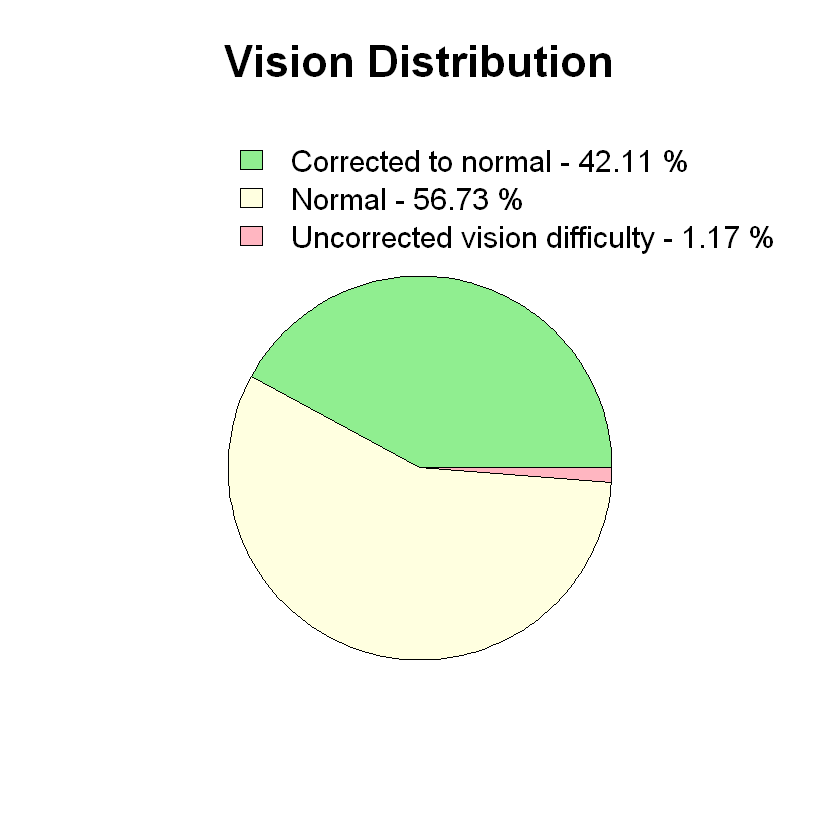

In [ ]:
# Vision distribution
vision_counts <- as.data.frame(table(demo_data_filtered$Vision))
colnames(vision_counts) <- c("Vision","Count")
vision_counts$Percent <- round((vision_counts$Count / sum(vision_counts$Count)) * 100, 2)

par(mar = c(1, 1, 5, 1))
pie(vision_counts$Percent,
    labels = NA,
    main = "Vision Distribution",
    col = c("lightgreen", "lightyellow", "lightpink"),
    radius = 0.6,
    cex.main = 2.2,
    cex = 1.5)
legend("topright",
       legend = paste(vision_counts$Vision, "-", vision_counts$Percent, "%"),
       fill = c("lightgreen", "lightyellow", "lightpink"),
       cex = 1.5,
       bty = "n")



## Exploratory Data Analysis


In [ ]:
abrupt_files[1]

[1] "./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv"

In [ ]:
# test one abrupt file
df_test <- read.csv(abrupt_files[1])
df_test_clean <- df_test %>%
  select(resp.corr) %>%
  filter(!is.na(resp.corr))

df_test_clean$resp.corr <- as.numeric(df_test_clean$resp.corr)
dim(df_test_clean)[1]
sum(df_test_clean == 1)

[1] 40

[1] 39

In [ ]:
# test one natural file
df_test_2 <- read.csv(natural_files[1])
df_test_clean_2 <- df_test_2 %>%
  select(resp.corr) %>%
  filter(!is.na(resp.corr))

df_test_clean_2$resp.corr <- as.numeric(df_test_clean_2$resp.corr)
dim(df_test_clean_2)[1]
sum(df_test_clean_2 == 1)

# natural_files[1]

[1] 40

[1] 33

In [ ]:
# Function to check for 'resp.corr' column in all files
check_resp_corr <- function(filepath) {
  df <- read.csv(filepath)
  if (!"resp.corr" %in% names(df)) {
    return(filepath)
  } else {
    return(NULL)
  }
}

missing_resp_corr <- lapply(combined_files, check_resp_corr)
missing_resp_corr <- unlist(missing_resp_corr[!sapply(missing_resp_corr, is.null)])

if (length(missing_resp_corr) > 0) {
  print("Files missing 'resp.corr' column:")
  print(missing_resp_corr)
} else {
  print("All files contain 'resp.corr' column.")
}

[1] "Files missing 'resp.corr' column:"
[1] "./BRSM data csv/BRSM data csv/BRSM data csv/sub42_NB_recognitionstage_2026-01-20_09h31.14.064.csv"


In [ ]:
test <- read.csv("./BRSM data csv/BRSM data csv/BRSM data csv/sub42_NB_recognitionstage_2026-01-20_09h31.14.064.csv")
colnames(test)

[1] "thisRow.t"            "notes"                "age"                 
 [4] "gender"               "handedness"           "vision"              
 [7] "caffeine_2h"          "alcohol_smoke_12h"    "demographics.started"
[10] "demographics.stopped" "Instructions.started" "text1.started"       
[13] "key_resp.started"     "participant"          "session"             
[16] "date"                 "expName"              "expVersion"          
[19] "psychopyVersion"      "frameRate"            "expStart"            
[22] "X"

The file: sub42_NB_recognitionstage_2026-01-20_09h31.14.064.csv does not contain the data necessary for the analysis as seen above. Therefore, it was excluded from the analysis.

In [ ]:
natural_files <- natural_files[natural_files != "./BRSM data csv/BRSM data csv/BRSM data csv/sub42_NB_recognitionstage_2026-01-20_09h31.14.064.csv"]

In [ ]:
combined_files <- combined_files[combined_files != "./BRSM data csv/BRSM data csv/BRSM data csv/sub42_NB_recognitionstage_2026-01-20_09h31.14.064.csv"]

In [ ]:
length(combined_files)

[1] 170

In [ ]:
# Function to check for the target_img column
check_targ_img <- function(filepath) {
  df <- read.csv(filepath)
  if (!"target_img" %in% names(df)) {
    return(filepath)
  } else {
    return(NULL)
  }
}

missing_targ_img <- lapply(combined_files, check_targ_img)
missing_targ_img <- unlist(missing_targ_img[!sapply(missing_targ_img, is.null)])


if (length(missing_targ_img) > 0) {
  print("Files missing 'target_img' column:")
  print(missing_targ_img)
} else {
  print("All files contain 'target_img' column.")
}

[1] "All files contain 'target_img' column."


In [ ]:
# Function to check for the 'instruction.2_stopped' column
check_col <- function(filepath) {
  df <- read.csv(filepath)
  if (!"instruction_2.stopped" %in% names(df)) {
    return(filepath)
  } else {
    return(NULL)
  }
}

missing_col <- lapply(combined_files, check_col)
missing_col <- unlist(missing_col[!sapply(missing_col, is.null)])

if (length(missing_col) > 0) {
  print("Files missing 'instruction.2_stopped' column:")
  print(missing_col)
} else {
  print("All files contain 'instruction.2_stopped' column.")
}

[1] "All files contain 'instruction.2_stopped' column."


In [ ]:
# Function to check for the 'Videos.stopped' column
check_col <- function(filepath) {
  df <- read.csv(filepath)
  if (!"Videos.stopped" %in% names(df)) {
    return(filepath)
  } else {
    return(NULL)
  }
}

missing_col <- lapply(combined_files, check_col)
missing_col <- unlist(missing_col[!sapply(missing_col, is.null)])

if (length(missing_col) > 0) {
  print("Files missing 'Videos.stopped' column:")
  print(missing_col)
} else {
  print("All files contain 'Videos.stopped' column.")
}

[1] "All files contain 'Videos.stopped' column."


### Vigilance Calculation

Anyone accounting for more than 27.05 minutes overall during the encoding stage, was considered inattentive. Assuming 25 secs for recognition of each repeated video before being skipped.

Samples labelled as unattentive were removed. Therefore, vigilance is used as an excusion criteria.

In [ ]:
head(combined_files)

[1] "./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv"
[2] "./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv"
[3] "./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv"
[4] "./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv"
[5] "./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv"
[6] "./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv"

In [ ]:
threshold_minutes <- 27.05

calculate_vigilance <- function(file_path) {
  result <- tryCatch({

    df <- read.csv(file_path)
    t_start_vec <- df$instruction_2.stopped[!is.na(df$instruction_2.stopped)]
    t_end_vec <- df$Videos.stopped[!is.na(df$Videos.stopped)]

    if(length(t_start_vec) == 0 || length(t_end_vec) == 0) {
      stop("Missing required timestamp columns or data")
    }

    t_start <- as.numeric(t_start_vec[1])
    t_end <- as.numeric(t_end_vec[1])

    duration_mins <- (t_end - t_start) / 60.0
    vigilance <- ifelse(duration_mins <= threshold_minutes, "Vigilant", "Not Vigilant")

    data.frame(
      subject = file_path,
      sub_ID = str_extract(file_path, "[Ss]ub\\d+_[A-Z]+"),
      encoding_duration = as.numeric(round(duration_mins, 2)),
      vigilance_status = vigilance,
      details = "Processed Successfully"
    )

  }, error = function(e) {
    data.frame(
      subject = file_path,
      sub_ID = str_extract(file_path, "[Ss]ub\\d+_[A-Z]+"),
      encoding_duration = NA,
      vigilance_status = "Error",
      details = as.character(e$message)
    )
  })

  return(result)
}

summary_df <- do.call(rbind, lapply(combined_files, calculate_vigilance))
head(summary_df)

,subject,sub_ID,encoding_duration,vigilance_status,details
,<chr>,<chr>,<dbl>,<chr>,<chr>
1,./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,sub100_AB,25.62,Vigilant,Processed Successfully
2,./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,sub101_AB,25.32,Vigilant,Processed Successfully
3,./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv,sub102_AB,24.82,Vigilant,Processed Successfully
4,./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv,sub103_AB,25.46,Vigilant,Processed Successfully
5,./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv,sub104_AB,25.36,Vigilant,Processed Successfully
6,./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv,sub105_AB,26.04,Vigilant,Processed Successfully


In [ ]:
table(summary_df$vigilance_status)


Not Vigilant     Vigilant 
           4          166 

In [ ]:
# Exclude subject from analysis if inattentive
summary_df <- summary_df %>%
  filter(vigilance_status == "Vigilant")

vigilant_subjects <- summary_df$sub_ID
is_attentive_file <- function(file_path, vigilant_subjects) {
  sub_id = str_extract(file_path, "[Ss]ub\\d+_[A-Z]+")
  return(sub_id %in% vigilant_subjects)
}

abrupt_files <- abrupt_files[sapply(abrupt_files, is_attentive_file, vigilant_subjects)]
natural_files <- natural_files[sapply(natural_files, is_attentive_file, vigilant_subjects)]
combined_files <- combined_files[sapply(combined_files, is_attentive_file, vigilant_subjects)]
demo_data_filtered <- demo_data_filtered %>%
  filter(`Sub ID` %in% vigilant_subjects)

In [ ]:
length(combined_files)

[1] 166

In [ ]:
length(demo_data_filtered$`Sub ID`)

[1] 166

In [ ]:
# Calculation of accuracy from resp.corr
get_accuracy <- function(filepath) {

  df <- read.csv(filepath)

  acc <- df %>%
    select(resp.corr) %>%
    mutate(resp.corr = as.numeric(resp.corr)) %>%
    filter(!is.na(resp.corr))

  total <- as.numeric(dim(acc)[1])
  total_1s <- sum(acc == 1)
  acc <- total_1s/total

  return(acc)
}


In [ ]:
# calculate accuracy for all files
all_accuracy <- lapply(combined_files, get_accuracy)
all_accuracy_df <- data.frame(
  subject = combined_files,
  sub_ID = str_extract(combined_files, "[Ss]ub\\d+_[A-Z]+"),
  accuracy = unlist(all_accuracy)
)

all_accuracy_df <- all_accuracy_df %>%
    mutate(group = case_when(
    grepl("NB", subject) ~ "Natural",
    grepl("AB", subject) ~ "Abrupt",
  ))
  head(all_accuracy_df)

,subject,sub_ID,accuracy,group
,<chr>,<chr>,<dbl>,<chr>
1,./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,sub100_AB,0.975,Abrupt
2,./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,sub101_AB,0.825,Abrupt
3,./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv,sub102_AB,0.850,Abrupt
4,./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv,sub103_AB,0.850,Abrupt
5,./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv,sub104_AB,0.825,Abrupt
6,./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv,sub105_AB,0.750,Abrupt


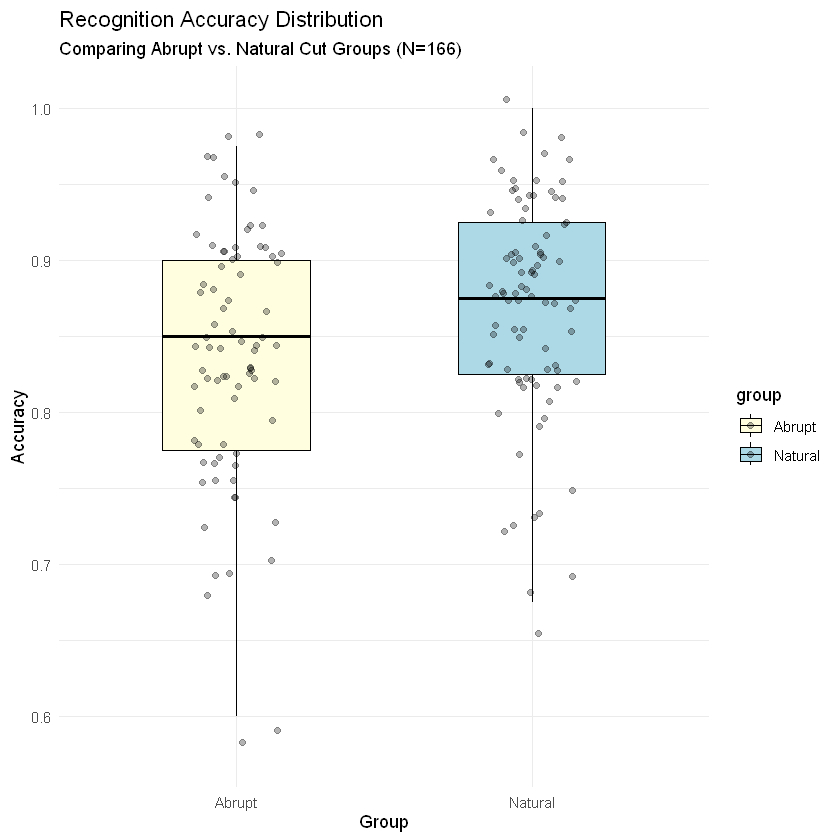

In [ ]:
# box plot
ggplot(all_accuracy_df, aes(x = group, y = accuracy, fill = group)) +
  geom_boxplot(width = 0.5, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Recognition Accuracy Distribution",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=166)",
       y = "Accuracy",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue"))

In [ ]:
summary_table <- all_accuracy_df %>%
  group_by(group) %>%
  summarize(
    Median_Value = median(accuracy, na.rm = TRUE),
    IQR_Value = IQR(accuracy, na.rm = TRUE),
    mean_accuracy = mean(accuracy),
    sd_accuracy = sd(accuracy),
    n = n())
summary_table

group,Median_Value,IQR_Value,mean_accuracy,sd_accuracy,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Abrupt,0.850,0.125,0.8376582,0.08222404,79
Natural,0.875,0.100,0.8704023,0.07269008,87


In [ ]:
# removing samples with accuracy > +/- 3 SDs from the mean
acc_mean <- mean(all_accuracy_df$accuracy, na.rm = TRUE)
acc_sd <- sd(all_accuracy_df$accuracy, na.rm = TRUE)
all_accuracy_df <- subset(all_accuracy_df,
                          accuracy < (acc_mean + 3 * acc_sd) &
                          accuracy > (acc_mean - 3 * acc_sd))
dim(all_accuracy_df)[1]

[1] 164

In [ ]:
# summary statistics after outlier removal
summary_table <- all_accuracy_df %>%
  group_by(group) %>%
  summarize(
    Median_Value = median(accuracy, na.rm = TRUE),
    IQR_Value = IQR(accuracy, na.rm = TRUE),
    mean_accuracy = mean(accuracy),
    sd_accuracy = sd(accuracy),
    n = n())
summary_table

group,Median_Value,IQR_Value,mean_accuracy,sd_accuracy,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Abrupt,0.850,0.1,0.8441558,0.07242238,77
Natural,0.875,0.1,0.8704023,0.07269008,87


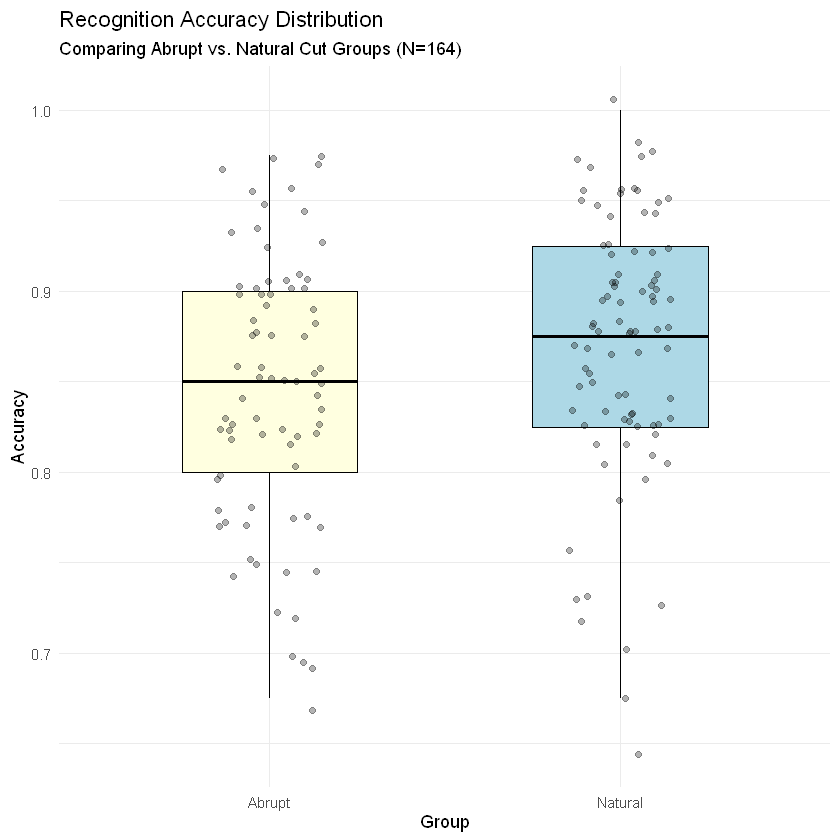

In [ ]:
# box plot after removing outliers
ggplot(all_accuracy_df, aes(x = group, y = accuracy, fill = group)) +
  geom_boxplot(width = 0.5, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Recognition Accuracy Distribution",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=164)",
       y = "Accuracy",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue"))+
  theme(legend.position = "none")

### Hypothesis Testing for Response Accuracy across two groups

H0: There is no significant difference in response accuracies of the two groups (Natural and Abrupt)  
  
HA: There is a significant difference in the response accuracies of the two groups (Two-tailed test)

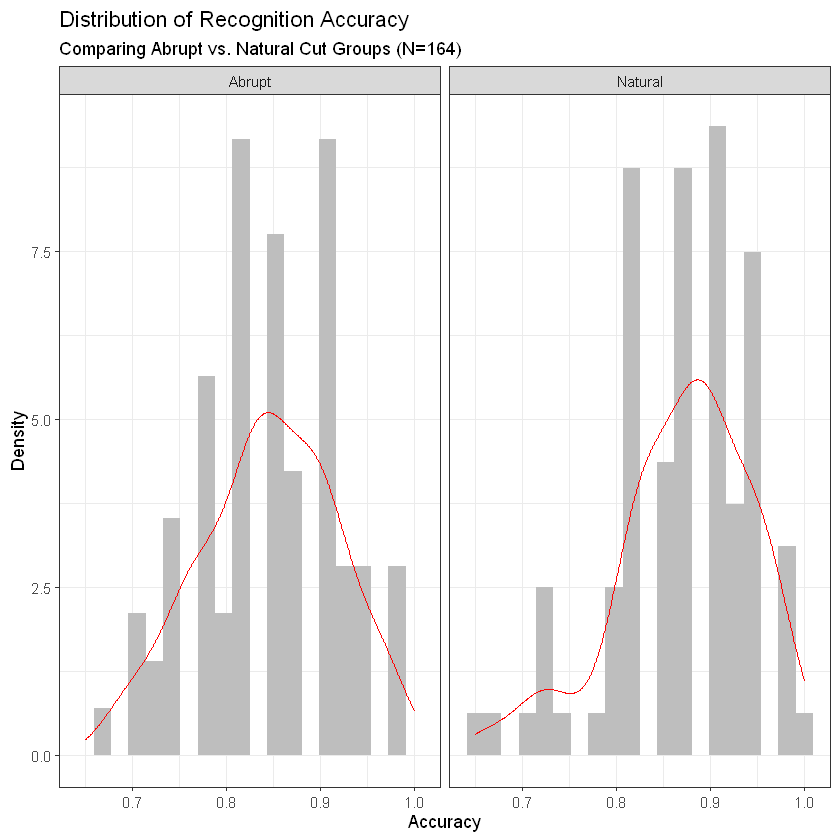

In [ ]:
# Histogram of the response accuracy data for the two groups
ggplot(all_accuracy_df, aes(x = accuracy)) +
  geom_histogram(aes(y = after_stat(density)), bins = 20, fill = "grey") +
  geom_density(color = "red") +
  facet_wrap(~group) +
  theme_bw() +
  labs(title = "Distribution of Recognition Accuracy",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=164)",
       x = "Accuracy",
       y = "Density")

The above histogram plot shows the distribution of the Response Accuracy data across the two groups (Natural and Abrupt) along with Kernel Density Estimate (KDE) curves.

The distributions for both groups are negatively skewed, indicating a high frequency of successful outcomes. While both groups peak above 80% accuracy, the Natural group displays more high-accuracy results, whereas the Abrupt group shows slightly more variance and more lower-accuracy outliers.


In [ ]:
# check normality
shapiro.test(all_accuracy_df$accuracy)


	Shapiro-Wilk normality test

data:  all_accuracy_df$accuracy
W = 0.96433, p-value = 0.0003173


The results of the Shapiro-Wilk tests indicate that the response accuracy data for both variables/groups significantly deviate from a normal distribution (p < 0.05).  
  
The Mann-Whitney U test (or Wilcoxon Rank-Sum test) was therefore selected to compare the Natural and Abrupt groups for response accuracy.

In [ ]:
# To check whether difference in accuracy is accounted for by the type of videos shown (abruptly cut/natural cut)
acc_wilcox_res <- wilcox.test(accuracy ~ group, data = all_accuracy_df, conf.int = TRUE, exact = FALSE)
print(acc_wilcox_res)


	Wilcoxon rank sum test with continuity correction

data:  accuracy by group
W = 2618.5, p-value = 0.01534
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -5.005935e-02 -5.862228e-05
sample estimates:
difference in location 
           -0.02506129 



In [ ]:
# Effect size calculation
wilcox_effsize(all_accuracy_df, accuracy ~ group)

,.y.,group1,group2,effsize,n1,n2,magnitude
,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<ord>
Effect size (r),accuracy,Abrupt,Natural,0.1894298,77,87,small


In [ ]:
# One tailed test to check if natural cut group has higher accuracy than abrupt cut group
acc_wilcox_res_onetailed <- wilcox.test(accuracy ~ group, data = all_accuracy_df, conf.int = TRUE, exact = FALSE, alternative = "less")
print(acc_wilcox_res_onetailed)


	Wilcoxon rank sum test with continuity correction

data:  accuracy by group
W = 2618.5, p-value = 0.007671
alternative hypothesis: true location shift is less than 0
95 percent confidence interval:
          -Inf -6.307194e-05
sample estimates:
difference in location 
           -0.02506129 



In [ ]:
levels(factor(all_accuracy_df$group))

[1] "Abrupt"  "Natural"

### Memory Sensitivity (d') Calculation
This metric is involved to reduce response bias by the subjects by differentiating between a participants actual memory strength and their tendency to say "old" regardless of the stimulus

In [ ]:
# calculation of d-prime
calc_dprime_2afc <- function(p_correct, n_trials) {
  p_adj <- (p_correct * n_trials + 0.5) / (n_trials + 1)
  # formula: d' = Z(P_correct) * sqrt(2)
  return(qnorm(p_adj) * sqrt(2))
}

all_data <- combined_files %>%
  map(~ {
    fname <- basename(.x)
    cond <- ifelse(grepl("_NB_", fname), "NB", ifelse(grepl("_AB_", fname), "AB", NA))

    temp_df <- tryCatch(read_csv(.x, show_col_types = FALSE), error = function(e) NULL)

    if (!is.null(temp_df) && "target_img" %in% colnames(temp_df) && !is.na(cond)) {
      temp_df %>%
        filter(!is.na(target_img)) %>%
        mutate(
          Subject = fname,
          Condition = cond,
          FrameType = ifelse(grepl("_BB_", target_img), "Before Boundary",
                      ifelse(grepl("_EM_", target_img), "Event Middle", "Other"))
        ) %>%
        select(Subject, Condition, FrameType, resp.corr)
    } else {
      return(NULL)
    }
  }) %>%
  bind_rows()

subject_summary <- all_data %>%
  group_by(Subject, Condition, FrameType) %>%
  summarize(
    Accuracy = mean(resp.corr, na.rm = TRUE),
    Trials = n(),
    .groups = "drop"
  ) %>%
  mutate(d_prime = map2_dbl(Accuracy, Trials, calc_dprime_2afc))

subject_summary_clean <- subject_summary %>%
  group_by(FrameType, Condition) %>%
  mutate(
    Mean_DP = mean(d_prime, na.rm = TRUE),
    SD_DP = sd(d_prime, na.rm = TRUE),
    Z_Score = (d_prime - Mean_DP) / SD_DP
  ) %>%
  filter(abs(Z_Score) <= 3) %>% # Keep only data within 3 SD
  ungroup() %>%
  select(-Mean_DP, -SD_DP, -Z_Score)
stats_summary <- subject_summary_clean %>%
  group_by(FrameType, Condition) %>%
  summarize(
    Mean_dprime = mean(d_prime, na.rm = TRUE),
    Median_dprime = median(d_prime, na.rm = TRUE),
    SD_dprime = sd(d_prime, na.rm = TRUE),
    N = n(),
    .groups = "drop"
  )




New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...101`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...101`
New names:
• `` -> `...103`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `...105`
New names:
• `` -> `...103`
New names:
• `` -> `...103`
New names:
• `` -> `...105`
New names:
• `` -> `

In [ ]:
head(subject_summary_clean)

Subject,Condition,FrameType,Accuracy,Trials,d_prime
<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>
Sub41_AB_recognitionstage_2026-01-19_17h56.12.732.csv,AB,Before Boundary,0.80,20,1.119546
Sub41_AB_recognitionstage_2026-01-19_17h56.12.732.csv,AB,Event Middle,0.90,20,1.668434
Sub43_NB_recognitionstage_2026-01-20_09h57.08.048.csv,NB,Before Boundary,1.00,20,2.801207
Sub43_NB_recognitionstage_2026-01-20_09h57.08.048.csv,NB,Event Middle,0.85,20,1.368141
sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,AB,Before Boundary,1.00,20,2.801207
sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,AB,Event Middle,0.95,20,2.072154


In [ ]:
# d-prime results
cat("\n---d' Scores stats ---\n")
print(stats_summary)


cat("\n--- T-Test---\n")
t_test <- subject_summary_clean %>%
filter(FrameType %in% c("Event Middle", "Before Boundary")) %>%
select(Subject, Condition, FrameType, d_prime) %>%
  pivot_wider(names_from = FrameType, values_from = d_prime) %>%
  rename(EM = `Event Middle`, BB = `Before Boundary`) %>%
  drop_na(EM, BB)

# Perform Paired Welch t-test
welch_result <- t.test(t_test$EM, t_test$BB,
                       paired = TRUE)
print(welch_result)


---d' Scores stats ---
# A tibble: 4 × 6
  FrameType       Condition Mean_dprime Median_dprime SD_dprime     N
  <chr>           <chr>           <dbl>         <dbl>     <dbl> <int>
1 Before Boundary AB               1.31          1.37     0.587    78
2 Before Boundary NB               1.53          1.37     0.592    87
3 Event Middle    AB               1.50          1.37     0.578    78
4 Event Middle    NB               1.66          1.67     0.532    87

--- T-Test---

	Paired t-test

data:  t_test$EM and t_test$BB
t = 3.0767, df = 164, p-value = 0.002453
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 0.05663062 0.25953281
sample estimates:
mean difference 
      0.1580817 



In [ ]:
cohens_d <- cohensD(t_test$EM, t_test$BB, method = "paired")
print(paste("Cohen's d:", round(cohens_d, 3)))

[1] "Cohen's d: 0.24"


In [ ]:
# One-tailed paired Welch t-test
# alternative = "greater" checks if the first group (EM) > second group (BB)
one_tailed_result <- t.test(t_test$EM, t_test$BB,
                            paired = TRUE,
                            alternative = "greater")

print(one_tailed_result)


	Paired t-test

data:  t_test$EM and t_test$BB
t = 3.0767, df = 164, p-value = 0.001227
alternative hypothesis: true mean difference is greater than 0
95 percent confidence interval:
 0.07308944        Inf
sample estimates:
mean difference 
      0.1580817 



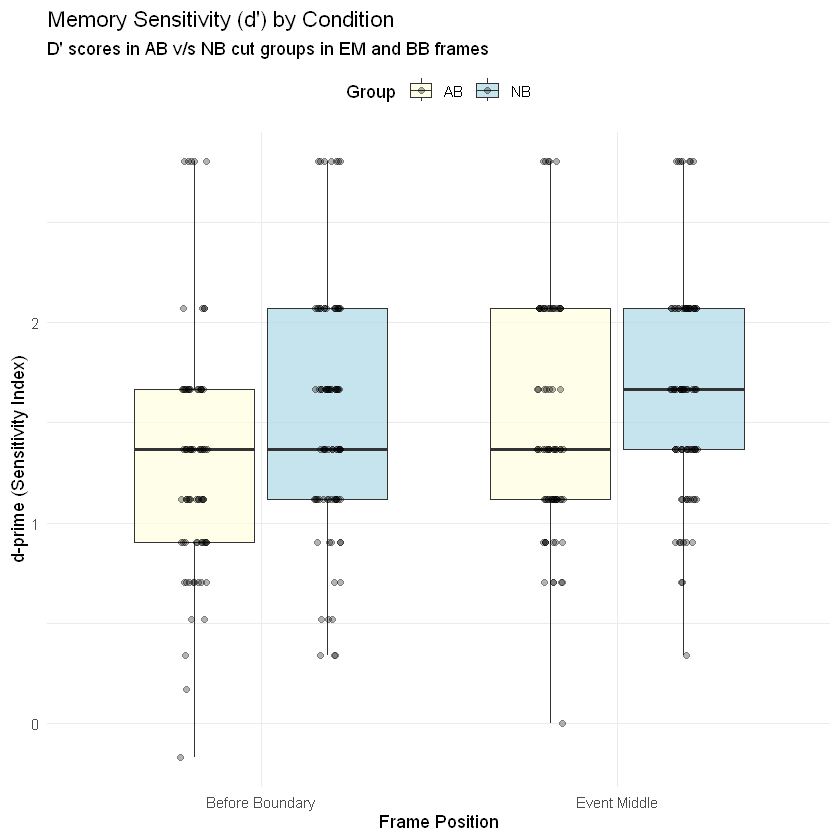

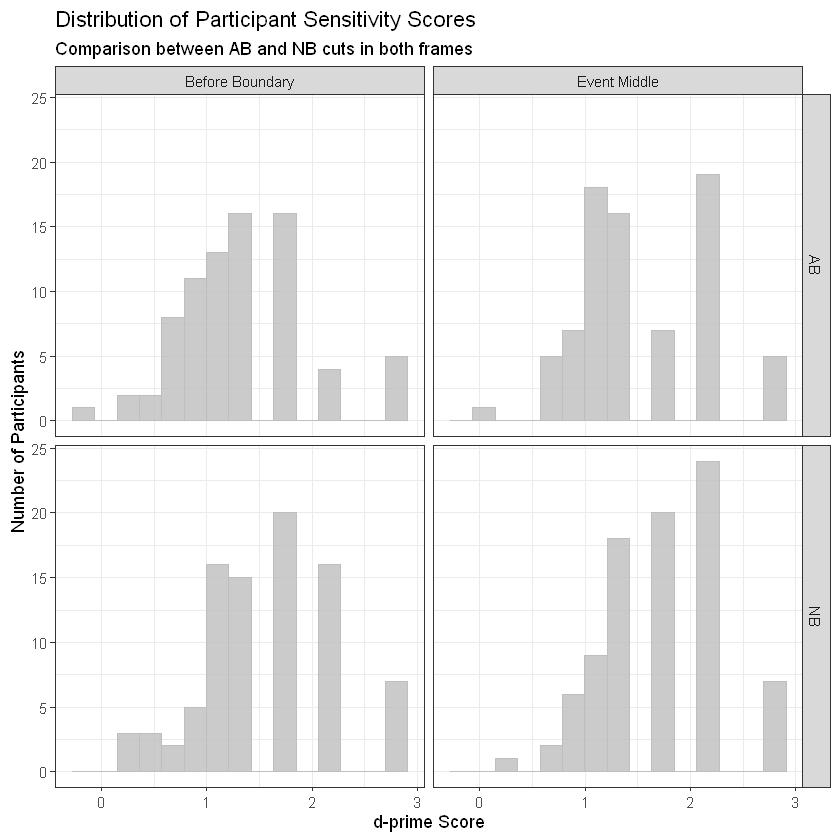

In [ ]:
# boxplot of d-prime scores by condition and frame type
p1 <- ggplot(subject_summary, aes(x = FrameType, y = d_prime, fill = Condition)) +
  geom_boxplot(alpha = 0.7, outlier.shape = NA) +

  geom_point(position = position_jitterdodge(jitter.width = 0.15),
             alpha = 0.3, size = 1.5) +
  theme_minimal() +
  labs(
    title = "Memory Sensitivity (d') by Condition",
    subtitle = "D' scores in AB v/s NB cut groups in EM and BB frames",
    x = "Frame Position",
    y = "d-prime (Sensitivity Index)",
    fill = "Group"
  ) +
  scale_fill_manual(values = c("AB" = "lightyellow", "NB" = "lightblue")) +
  theme(legend.position = "top")


p2 <- ggplot(subject_summary, aes(x = d_prime, fill = Condition)) +
  geom_histogram(alpha = 0.8, bins = 15, color = "grey") +
  facet_grid(Condition ~ FrameType) +
  theme_bw() +
  labs(
    title = "Distribution of Participant Sensitivity Scores",
    subtitle = "Comparison between AB and NB cuts in both frames",
    x = "d-prime Score",
    y = "Number of Participants"
  ) +
  scale_fill_manual(values = c("AB" = "grey", "NB" = "grey")) +
  theme(legend.position = "none")


print(p1)
print(p2)

## Calculating Mean Response Time

A correct response reflects the speed of successful information processing. An error often reflects a "fast guess" (low RT) or a momentary lapse in attention/distraction (high RT). If one group (e.g., Abrupt cuts) has faster RTs but significantly more errors, they might just be rushing. Including those fast, incorrect RTs would falsely make the group look "more efficient" than they actually are.

In [ ]:
# Calculation of mean response time
get_mean_rt <- function(filepath) {
  df <- read.csv(filepath)
  df <- df %>%
    filter(resp.corr == 1)
  rt_vector <- df %>%
    pull(resp.rt)
  rt_vector <- rt_vector[!is.na(rt_vector) & rt_vector != ""]
  numeric_rt <- parse_number(as.character(rt_vector))
  mean_rt <- mean(numeric_rt, na.rm = TRUE)
  return(mean_rt)
}


In [ ]:
# calculate response time for all files
all_resp.rt <- lapply(combined_files, get_mean_rt)
all_resp.rt_df <- data.frame(
  subject = combined_files,
  sub_ID = str_extract(combined_files, "[Ss]ub\\d+_[A-Z]+"),
  mean_rt = unlist(all_resp.rt)
)

all_resp.rt_df <- all_resp.rt_df %>%
    mutate(group = case_when(
    grepl("NB", subject) ~ "Natural",
    grepl("AB", subject) ~ "Abrupt",
  ))
  head(all_resp.rt_df)

,subject,sub_ID,mean_rt,group
,<chr>,<chr>,<dbl>,<chr>
1,./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,sub100_AB,9.409506,Abrupt
2,./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,sub101_AB,5.306544,Abrupt
3,./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv,sub102_AB,4.724642,Abrupt
4,./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv,sub103_AB,4.201918,Abrupt
5,./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv,sub104_AB,3.733099,Abrupt
6,./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv,sub105_AB,5.660510,Abrupt


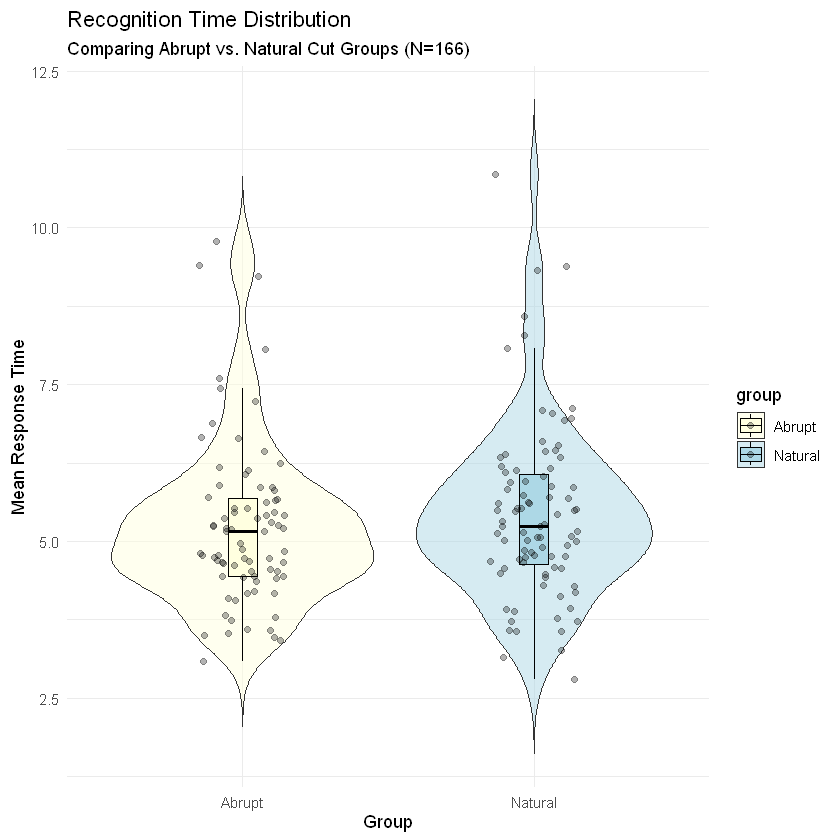

In [ ]:
# violin plot
ggplot(all_resp.rt_df, aes(x = group, y = mean_rt, fill = group)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.1, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Recognition Time Distribution",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=166)",
       y = "Mean Response Time",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue"))

In [ ]:
summary_table <- all_resp.rt_df %>%
  group_by(group) %>%
  summarize(
    n = n(),
    Median = median(mean_rt, na.rm = TRUE),
    IQR = IQR(mean_rt, na.rm = TRUE),
    Min = min(mean_rt, na.rm = TRUE),
    Max = max(mean_rt, na.rm = TRUE)
  )

summary_table

group,n,Median,IQR,Min,Max
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Abrupt,79,5.150747,1.237653,3.077296,9.779291
Natural,87,5.237959,1.444568,2.790255,10.858324


In [ ]:
# removing samples with mean RT > +/- 3 SDs from the mean
rt_mean <- mean(all_resp.rt_df$mean_rt, na.rm = TRUE)
rt_sd <- sd(all_resp.rt_df$mean_rt, na.rm = TRUE)
all_resp.rt_df <- subset(all_resp.rt_df,
                         mean_rt < (rt_mean + 3 * rt_sd) &
                         mean_rt > (rt_mean - 3 * rt_sd))
dim(all_resp.rt_df)[1]

[1] 164

In [ ]:
# summary table after outlier removal
summary_table <- all_resp.rt_df %>%
  group_by(group) %>%
  summarize(
    n = n(),
    Median = median(mean_rt, na.rm = TRUE),
    IQR = IQR(mean_rt, na.rm = TRUE),
    Min = min(mean_rt, na.rm = TRUE),
    Max = max(mean_rt, na.rm = TRUE)
  )

summary_table

group,n,Median,IQR,Min,Max
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Abrupt,78,5.057062,1.218839,3.077296,9.409506
Natural,86,5.235693,1.416182,2.790255,9.393027


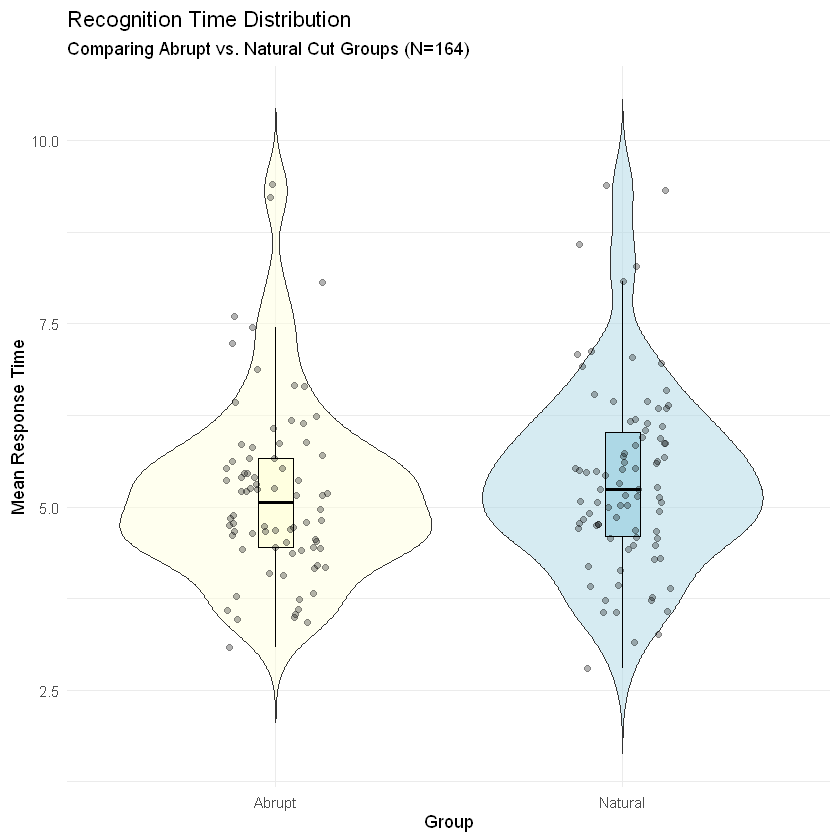

In [ ]:
# violin plot after removing outliers
ggplot(all_resp.rt_df, aes(x = group, y = mean_rt, fill = group)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.1, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Recognition Time Distribution",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=164)",
       y = "Mean Response Time",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue"))+
  # remove legend
  theme(legend.position = "none")

### Hypothesis Testing for Response Time across the two groups   
  
H0: There is no significant difference in response times of the two groups (Natural and Abrupt)  
  
HA: There is a significant difference in the response times of the two groups (Two-tailed test)

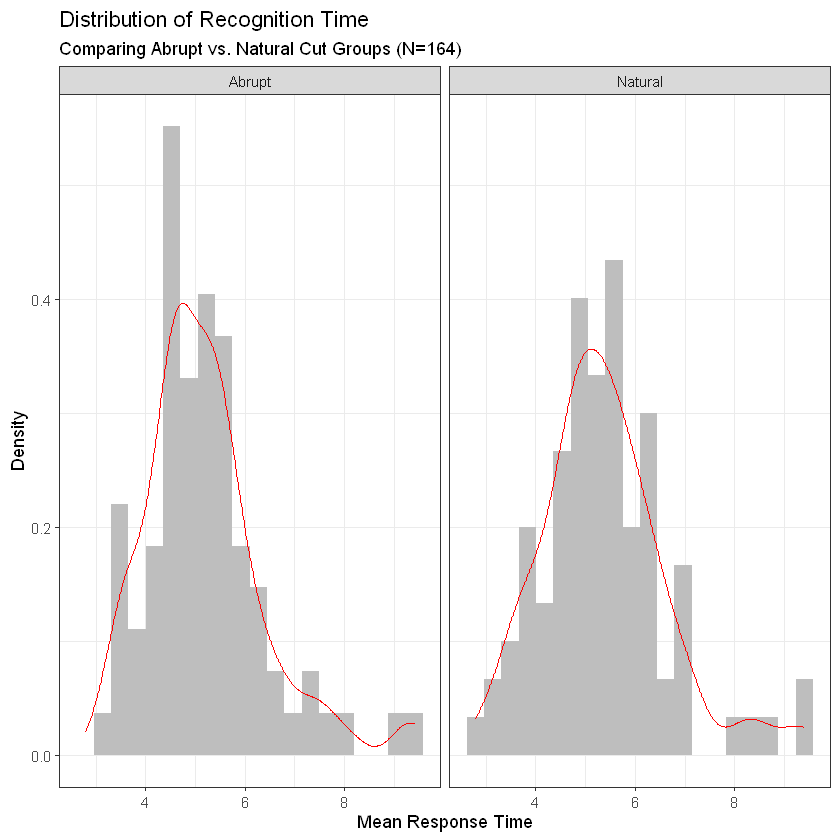

In [ ]:
ggplot(all_resp.rt_df, aes(x = mean_rt)) +
  geom_histogram(aes(y = after_stat(density)), bins = 20, fill = "grey") +
  geom_density(color = "red") +
  facet_wrap(~group) +
  theme_bw()+
  labs(title = "Distribution of Recognition Time",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=164)",
       x = "Mean Response Time",
       y = "Density")

In [ ]:
# check normality
shapiro.test(all_resp.rt_df$mean_rt[all_resp.rt_df$group == "Natural"])
shapiro.test(all_resp.rt_df$mean_rt[all_resp.rt_df$group == "Abrupt"])


	Shapiro-Wilk normality test

data:  all_resp.rt_df$mean_rt[all_resp.rt_df$group == "Natural"]
W = 0.9549, p-value = 0.004434



	Shapiro-Wilk normality test

data:  all_resp.rt_df$mean_rt[all_resp.rt_df$group == "Abrupt"]
W = 0.92235, p-value = 0.0001498


The results of the Shapiro-Wilk tests indicate that the response time data for both variables/groups significantly deviate from a normal distribution (p < 0.05).

The Mann-Whitney U test (or Wilcoxon Rank-Sum test) was therefore selected to compare the Natural and Abrupt groups for response time.

In [ ]:
test_res <- wilcox.test(mean_rt ~ group, all_resp.rt_df, conf.int = TRUE, exact = FALSE)
print(test_res)


	Wilcoxon rank sum test with continuity correction

data:  mean_rt by group
W = 2959, p-value = 0.194
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -0.5472408  0.1263966
sample estimates:
difference in location 
            -0.2231513 



The results demonstrate that while the Natural group exhibited significantly higher accuracy, their response times were statistically comparable to the Abrupt group. This suggests that Natural Cut videos facilitate better information processing leading to higher accuracy but do not necessarily lead to a quicker response time.

### Boundary-related Memory Effects

Calculating Recognition accuracy for pre-boundary (BB) frames

In [ ]:
# Calculation of BB accuracy from resp.corr
get_BB_accuracy <- function(filepath) {
  df <- read.csv(filepath)
  bb_data <- df %>%
    filter(grepl("BB", target_img)) %>%
      select(resp.corr) %>%
      mutate(resp.corr = as.numeric(resp.corr)) %>%
      filter(!is.na(resp.corr))

  total <- as.numeric(dim(bb_data)[1])
  total_1s <- sum(bb_data$resp.corr == 1)
  accuracy <- total_1s/total

  return(accuracy)
}



In [ ]:
# calculate accuracy for all files
all_BB_accuracy <- lapply(combined_files, get_BB_accuracy)
all_BB_accuracy_df <- data.frame(
  subject = combined_files,
  sub_ID = str_extract(combined_files, "[Ss]ub\\d+_[A-Z]+"),
  accuracy = unlist(all_BB_accuracy)
)

all_BB_accuracy_df <- all_BB_accuracy_df %>%
    mutate(group = case_when(
    grepl("NB", subject) ~ "Natural",
    grepl("AB", subject) ~ "Abrupt",
  ))
  head(all_BB_accuracy_df)

,subject,sub_ID,accuracy,group
,<chr>,<chr>,<dbl>,<chr>
1,./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,sub100_AB,1.00,Abrupt
2,./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,sub101_AB,0.65,Abrupt
3,./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv,sub102_AB,0.80,Abrupt
4,./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv,sub103_AB,0.85,Abrupt
5,./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv,sub104_AB,0.85,Abrupt
6,./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv,sub105_AB,0.70,Abrupt


In [ ]:
dim(all_BB_accuracy_df)[1]

[1] 166

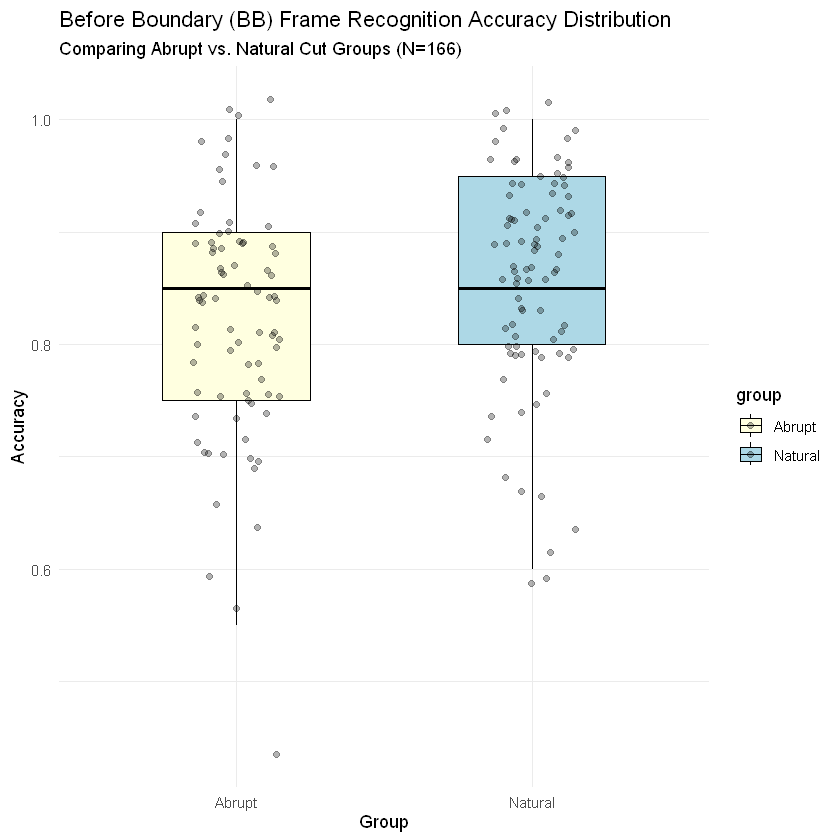

In [ ]:
# box plot
ggplot(all_BB_accuracy_df, aes(x = group, y = accuracy, fill = group)) +
  geom_boxplot(width = 0.5, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Before Boundary (BB) Frame Recognition Accuracy Distribution",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=166)",
       y = "Accuracy",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue"))

In [ ]:
summary_BB <- all_BB_accuracy_df %>%
  group_by(group) %>%
  summarize(
    median_accuracy = median(accuracy, na.rm = TRUE),
    IQR = IQR(accuracy, na.rm = TRUE),
    mean_accuracy = mean(accuracy),
    sd_accuracy = sd(accuracy),
    n = n())
summary_BB

group,median_accuracy,IQR,mean_accuracy,sd_accuracy,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Abrupt,0.85,0.15,0.821519,0.1046004,79
Natural,0.85,0.15,0.858046,0.0967115,87


In [ ]:
# removing samples with accuracy > +/- 3 SDs from the mean
bb_acc_mean <- mean(all_BB_accuracy_df$accuracy, na.rm = TRUE)
bb_acc_sd <- sd(all_BB_accuracy_df$accuracy, na.rm = TRUE)
all_BB_accuracy_df <- all_BB_accuracy_df[all_BB_accuracy_df$accuracy < bb_acc_mean + 3 * bb_acc_sd, ]
all_BB_accuracy_df <- all_BB_accuracy_df[all_BB_accuracy_df$accuracy > bb_acc_mean - 3 * bb_acc_sd, ]
dim(all_BB_accuracy_df)[1]

[1] 165

In [ ]:
# summary statistics after outlier removal
summary_BB <- all_BB_accuracy_df %>%
  group_by(group) %>%
  summarize(
    median_accuracy = median(accuracy, na.rm = TRUE),
    IQR = IQR(accuracy, na.rm = TRUE),
    mean_accuracy = mean(accuracy),
    sd_accuracy = sd(accuracy),
    n = n())
summary_BB

group,median_accuracy,IQR,mean_accuracy,sd_accuracy,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Abrupt,0.85,0.15,0.8298701,0.09150055,77
Natural,0.85,0.15,0.8580460,0.09671150,87


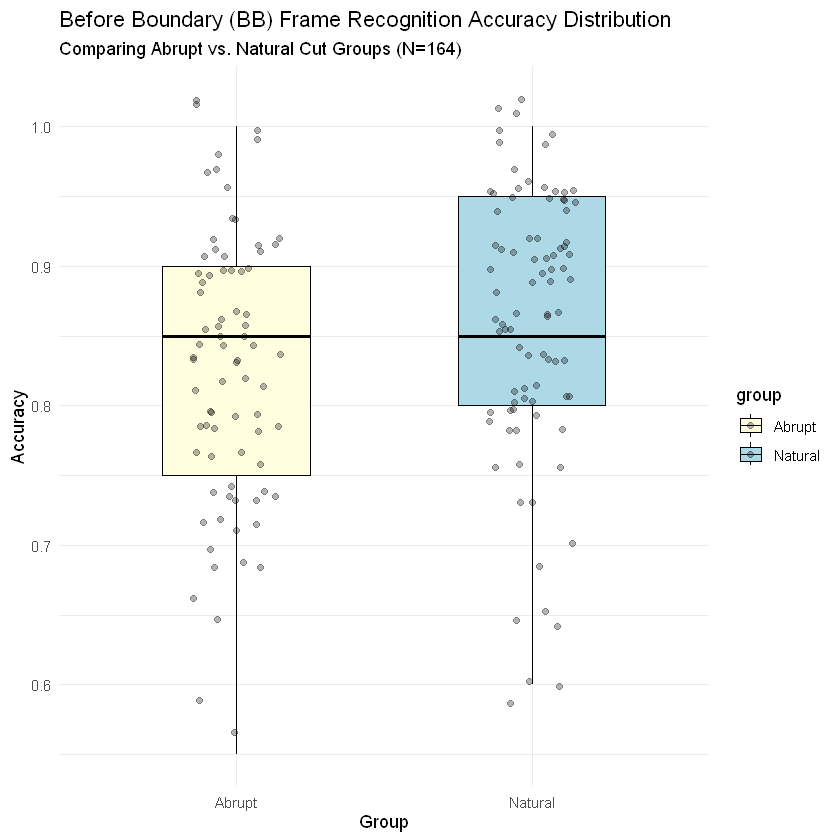

In [ ]:
# box plot
ggplot(all_BB_accuracy_df, aes(x = group, y = accuracy, fill = group)) +
  geom_boxplot(width = 0.5, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Before Boundary (BB) Frame Recognition Accuracy Distribution",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=164)",
       y = "Accuracy",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue"))

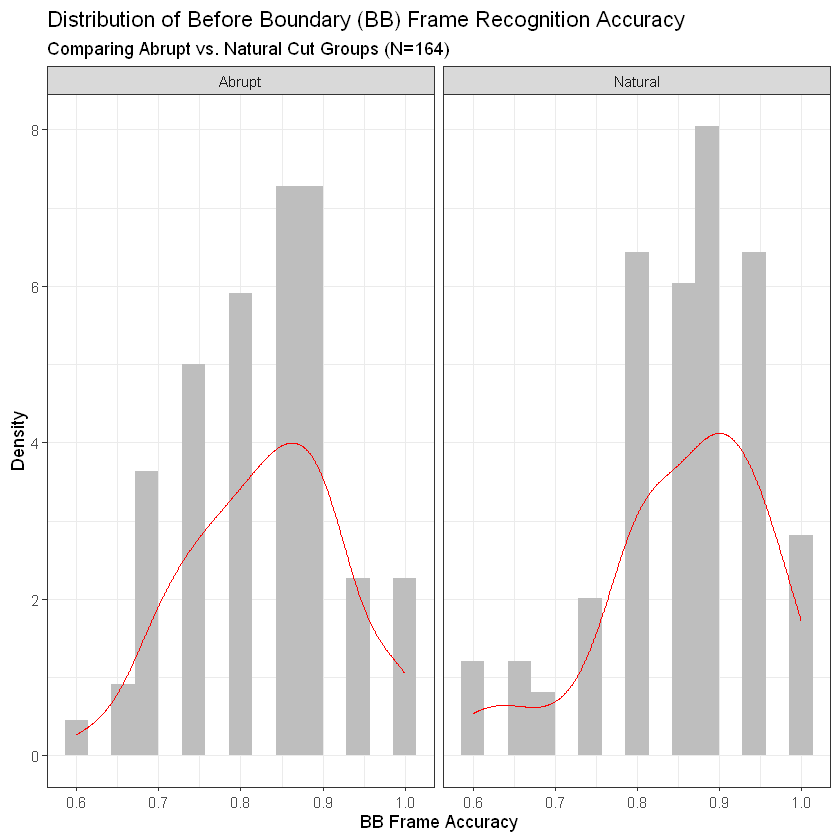

In [ ]:
# Histogram of the EM response accuracy data for the two groups
ggplot(all_BB_accuracy_df, aes(x = accuracy)) +
  geom_histogram(aes(y = after_stat(density)), bins = 15, fill = "grey") +
  geom_density(color = "red") +
  facet_wrap(~group) +
  theme_bw()+
  labs(title = "Distribution of Before Boundary (BB) Frame Recognition Accuracy",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=164)",
       x = "BB Frame Accuracy",
       y = "Density")

In [ ]:
# remove outliers above +/- 3 SDs from the mean
bb_mean <- mean(all_BB_accuracy_df$accuracy, na.rm = TRUE)
bb_sd <- sd(all_BB_accuracy_df$accuracy, na.rm = TRUE)
all_BB_accuracy_df <- subset(all_BB_accuracy_df,
                         accuracy < (bb_mean + 3 * bb_sd) &
                         accuracy > (bb_mean - 3 * bb_sd))
dim(all_BB_accuracy_df)[1]

[1] 164

In [ ]:
# check normality
shapiro.test(all_BB_accuracy_df$accuracy[all_BB_accuracy_df$group == "Natural"])
shapiro.test(all_BB_accuracy_df$accuracy[all_BB_accuracy_df$group == "Abrupt"])


	Shapiro-Wilk normality test

data:  all_BB_accuracy_df$accuracy[all_BB_accuracy_df$group == "Natural"]
W = 0.92182, p-value = 5.89e-05



	Shapiro-Wilk normality test

data:  all_BB_accuracy_df$accuracy[all_BB_accuracy_df$group == "Abrupt"]
W = 0.96374, p-value = 0.0271


In [ ]:
# To check whether difference in BB accuracy is accounted for by the type of videos shown (abruptly cut/natural cut)
BB_wilcox_res <- wilcox.test(accuracy ~ group, data = all_BB_accuracy_df, conf.int = TRUE, exact = FALSE)
print(BB_wilcox_res)


	Wilcoxon rank sum test with continuity correction

data:  accuracy by group
W = 2680.5, p-value = 0.02559
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -5.00108e-02 -4.61329e-05
sample estimates:
difference in location 
           -0.04995058 



In [ ]:
# one tailed test to check if natural cut group has higher BB accuracy than abrupt cut group
BB_wilcox_res_onetailed <- wilcox.test(accuracy ~ group, data = all_BB_accuracy_df, conf.int = TRUE, exact = FALSE, alternative = "less")
print(BB_wilcox_res_onetailed)


	Wilcoxon rank sum test with continuity correction

data:  accuracy by group
W = 2680.5, p-value = 0.01279
alternative hypothesis: true location shift is less than 0
95 percent confidence interval:
          -Inf -5.533676e-05
sample estimates:
difference in location 
           -0.04995058 



In [ ]:
levels(factor(all_BB_accuracy_df$group))

[1] "Abrupt"  "Natural"

Computing Abrupt and Natural Group Response Accuracy for Event-Middle (EM) frames

In [ ]:
# Calculation of EM accuracy from resp.corr
get_EM_accuracy <- function(filepath) {
  df <- read.csv(filepath)
  em_data <- df %>%
    filter(grepl("EM", target_img)) %>%
      select(resp.corr) %>%
      mutate(resp.corr = as.numeric(resp.corr)) %>%
      filter(!is.na(resp.corr))

  total <- as.numeric(dim(em_data)[1])
  total_1s <- sum(em_data$resp.corr == 1)
  accuracy <- total_1s/total
  return(accuracy)
}



In [ ]:
# calculate accuracy for all files
all_EM_accuracy <- lapply(combined_files, get_EM_accuracy)
all_EM_accuracy_df <- data.frame(
  subject = combined_files,
  sub_ID = str_extract(combined_files, "[Ss]ub\\d+_[A-Z]+"),
  accuracy = unlist(all_EM_accuracy)
)

all_EM_accuracy_df <- all_EM_accuracy_df %>%
    mutate(group = case_when(
    grepl("NB", subject) ~ "Natural",
    grepl("AB", subject) ~ "Abrupt",
  ))
  head(all_EM_accuracy_df)

,subject,sub_ID,accuracy,group
,<chr>,<chr>,<dbl>,<chr>
1,./BRSM data csv/BRSM data csv/BRSM data csv/sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,sub100_AB,0.95,Abrupt
2,./BRSM data csv/BRSM data csv/BRSM data csv/sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,sub101_AB,1.00,Abrupt
3,./BRSM data csv/BRSM data csv/BRSM data csv/sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv,sub102_AB,0.90,Abrupt
4,./BRSM data csv/BRSM data csv/BRSM data csv/sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv,sub103_AB,0.85,Abrupt
5,./BRSM data csv/BRSM data csv/BRSM data csv/sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv,sub104_AB,0.80,Abrupt
6,./BRSM data csv/BRSM data csv/BRSM data csv/sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv,sub105_AB,0.80,Abrupt


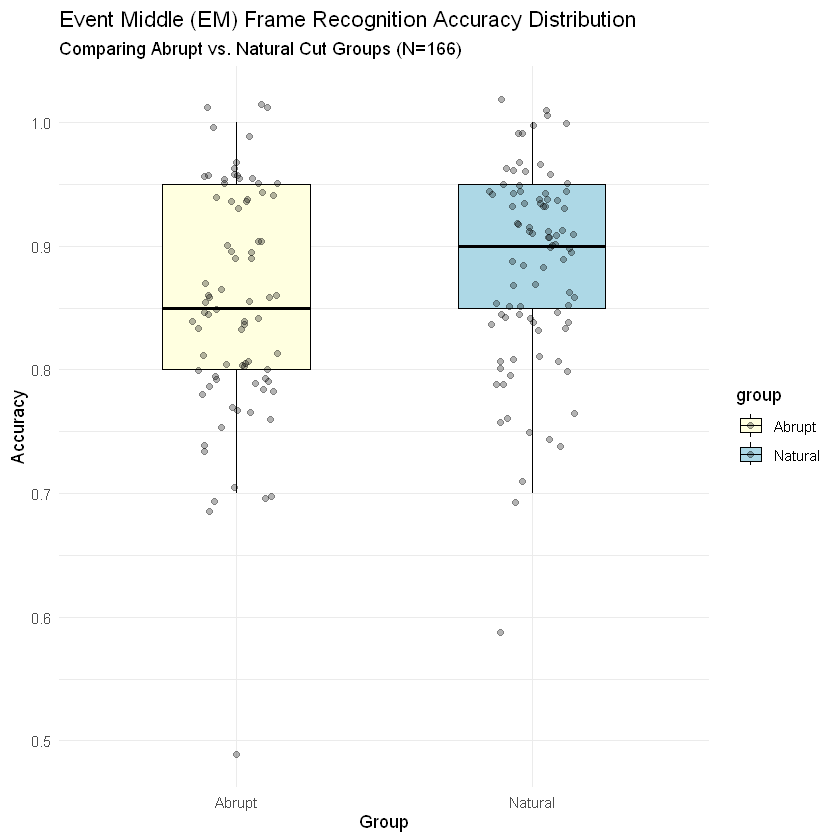

In [ ]:
# box plot
ggplot(all_EM_accuracy_df, aes(x = group, y = accuracy, fill = group)) +
  geom_boxplot(width = 0.5, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Event Middle (EM) Frame Recognition Accuracy Distribution",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=166)",
       y = "Accuracy",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue"))

In [ ]:
summary_EM <- all_EM_accuracy_df %>%
  group_by(group) %>%
  summarize(
    median_accuracy = median(accuracy, na.rm = TRUE),
    IQR = IQR(accuracy, na.rm = TRUE),
    mean_accuracy = mean(accuracy),
    sd_accuracy = sd(accuracy),
    n = n())
summary_EM

group,median_accuracy,IQR,mean_accuracy,sd_accuracy,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Abrupt,0.85,0.15,0.8537975,0.09260204,79
Natural,0.90,0.10,0.8827586,0.07954361,87


In [ ]:
# remove outliers above +/- 3 SDs from the mean
em_mean <- mean(all_EM_accuracy_df$accuracy, na.rm = TRUE)
em_sd <- sd(all_EM_accuracy_df$accuracy, na.rm = TRUE)
all_EM_accuracy_df <- subset(all_EM_accuracy_df,
                         accuracy < (em_mean + 3 * em_sd) &
                         accuracy > (em_mean - 3 * em_sd))
dim(all_EM_accuracy_df)[1]

[1] 164

In [ ]:
# summary statistics after outlier removal
summary_EM <- all_EM_accuracy_df %>%
  group_by(group) %>%
  summarize(
    median_accuracy = median(accuracy, na.rm = TRUE),
    IQR = IQR(accuracy, na.rm = TRUE),
    mean_accuracy = mean(accuracy),
    sd_accuracy = sd(accuracy),
    n = n())
summary_EM

group,median_accuracy,IQR,mean_accuracy,sd_accuracy,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Abrupt,0.85,0.15,0.8583333,0.08390497,78
Natural,0.90,0.10,0.8860465,0.07382458,86


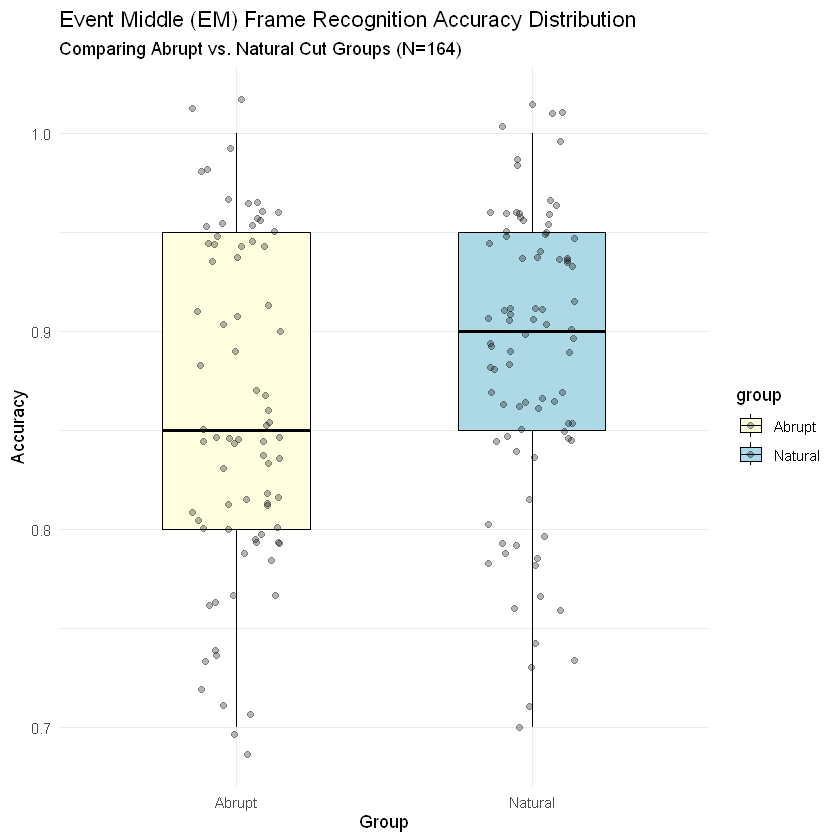

In [ ]:
# box plot
ggplot(all_EM_accuracy_df, aes(x = group, y = accuracy, fill = group)) +
  geom_boxplot(width = 0.5, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  theme_minimal() +
  labs(title = "Event Middle (EM) Frame Recognition Accuracy Distribution",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=164)",
       y = "Accuracy",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue"))

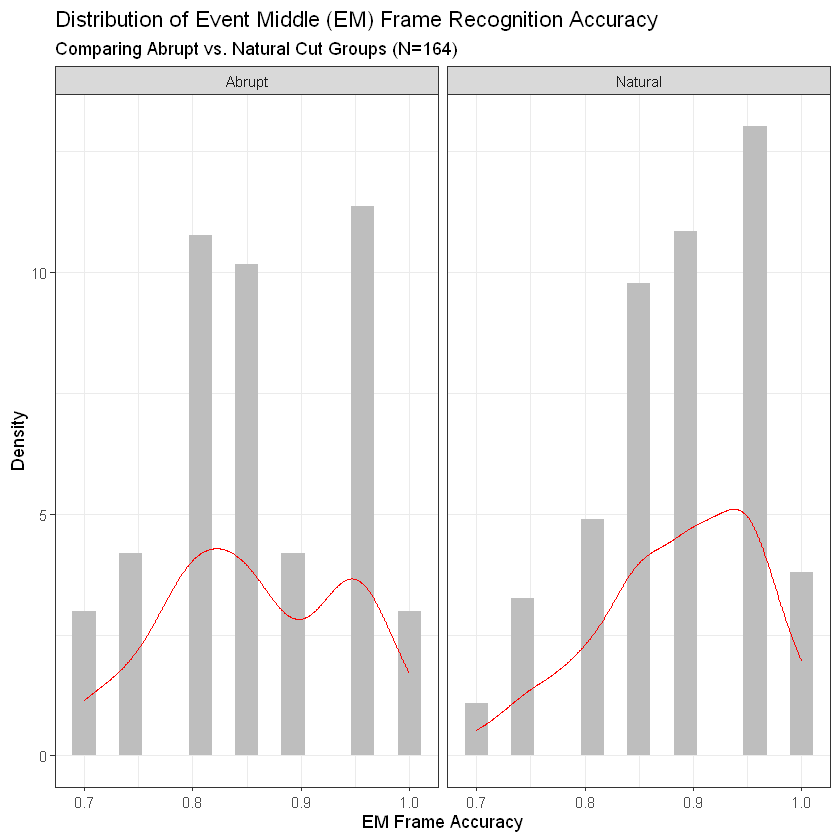

In [ ]:
# Histogram of the EM response accuracy data for the two groups
ggplot(all_EM_accuracy_df, aes(x = accuracy)) +
  geom_histogram(aes(y = after_stat(density)), bins = 15, fill = "grey") +
  geom_density(color = "red") +
  facet_wrap(~group) +
  theme_bw()+
  labs(title = "Distribution of Event Middle (EM) Frame Recognition Accuracy",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=164)",
       x = "EM Frame Accuracy",
       y = "Density")

In [ ]:
# check normality
shapiro.test(all_EM_accuracy_df$accuracy[all_EM_accuracy_df$group == "Natural"])
shapiro.test(all_EM_accuracy_df$accuracy[all_EM_accuracy_df$group == "Abrupt"])


	Shapiro-Wilk normality test

data:  all_EM_accuracy_df$accuracy[all_EM_accuracy_df$group == "Natural"]
W = 0.92684, p-value = 0.0001161



	Shapiro-Wilk normality test

data:  all_EM_accuracy_df$accuracy[all_EM_accuracy_df$group == "Abrupt"]
W = 0.93001, p-value = 0.0003514


In [ ]:
# To check whether difference in EM accuracy is accounted for by the type of videos shown (abruptly cut/natural cut)
EM_wilcox_res <- wilcox.test(accuracy ~ group, data = all_EM_accuracy_df, conf.int = TRUE, exact = FALSE)
print(EM_wilcox_res)


	Wilcoxon rank sum test with continuity correction

data:  accuracy by group
W = 2707.5, p-value = 0.03014
alternative hypothesis: true location shift is not equal to 0
95 percent confidence interval:
 -5.003644e-02 -5.839477e-06
sample estimates:
difference in location 
           -0.04999767 



In [ ]:
# one tailed test to check if natural cut group has higher EM accuracy than abrupt cut group
EM_wilcox_res_onetailed <- wilcox.test(accuracy ~ group, data = all_EM_accuracy_df, conf.int = TRUE, exact = FALSE, alternative = "less")
print(EM_wilcox_res_onetailed)


	Wilcoxon rank sum test with continuity correction

data:  accuracy by group
W = 2707.5, p-value = 0.01507
alternative hypothesis: true location shift is less than 0
95 percent confidence interval:
          -Inf -6.067032e-05
sample estimates:
difference in location 
           -0.04999767 



In [ ]:
levels(factor(all_EM_accuracy_df$group))

[1] "Abrupt"  "Natural"

Is there any significant difference in accuracies between EM and BB frame recognition?

In [ ]:
get_df <- function(filepath) {

  df <- read.csv(filepath)
  results <- df %>%
    summarise(
      EM_accuracy = mean(as.numeric(resp.corr[grepl("EM", target_img)]) == 1, na.rm = TRUE),
      BB_accuracy = mean(as.numeric(resp.corr[grepl("BB", target_img)]) == 1, na.rm = TRUE),
    ) %>%
    mutate(
      subject = basename(filepath)
    ) %>%
    select(subject, EM_accuracy, BB_accuracy)

  return(results)
}

EM_BB_df <- combined_files %>%
  map_df(~get_df(.x))
head(EM_BB_df)

,subject,EM_accuracy,BB_accuracy
,<chr>,<dbl>,<dbl>
1,sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,0.95,1.00
2,sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,1.00,0.65
3,sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv,0.90,0.80
4,sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv,0.85,0.85
5,sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv,0.80,0.85
6,sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv,0.80,0.70


In [ ]:
dim(EM_BB_df)

[1] 166   3

In [ ]:
# remove outliers above +/- 3 SDs from the mean
em_mean <- mean(EM_BB_df$EM_accuracy, na.rm = TRUE)
em_sd <- sd(EM_BB_df$EM_accuracy, na.rm = TRUE)
bb_mean <- mean(EM_BB_df$BB_accuracy, na.rm = TRUE)
bb_sd <- sd(EM_BB_df$BB_accuracy, na.rm = TRUE)
EM_BB_df <- subset(EM_BB_df,
                         EM_accuracy < (em_mean + 3 * em_sd) &
                         EM_accuracy > (em_mean - 3 * em_sd) &
                         BB_accuracy < (bb_mean + 3 * bb_sd) &
                         BB_accuracy > (bb_mean - 3 * bb_sd))
dim(EM_BB_df)[1]

[1] 163

In [ ]:
wilcox_result <- wilcox.test(EM_BB_df$EM_accuracy,
                             EM_BB_df$BB_accuracy,
                             paired = TRUE, exact = FALSE)

print(wilcox_result)


	Wilcoxon signed rank test with continuity correction

data:  EM_BB_df$EM_accuracy and EM_BB_df$BB_accuracy
V = 5467.5, p-value = 0.001368
alternative hypothesis: true location shift is not equal to 0



In [ ]:
# Extracting the Z-statistic from the p-value and calculating r
z_val <- qnorm(wilcox_result$p.value / 2)
r_val <- abs(z_val / sqrt(nrow(EM_BB_df)))

print(paste("Effect Size r:", round(r_val, 3)))

[1] "Effect Size r: 0.251"


In [ ]:
# Checking directionality using a one-tailed test
wilcox_result_one_tailed <- wilcox.test(EM_BB_df$EM_accuracy,
                                     EM_BB_df$BB_accuracy,
                                     paired = TRUE,
                                     exact = FALSE,
                                     alternative = "greater")
print(wilcox_result_one_tailed)


	Wilcoxon signed rank test with continuity correction

data:  EM_BB_df$EM_accuracy and EM_BB_df$BB_accuracy
V = 5467.5, p-value = 0.000684
alternative hypothesis: true location shift is greater than 0



Participants are significantly better at recognizing the middle-event (EM) frames than the boundary-boundary (BB) frames.

#### Does participant confidence accurately reflect their actual recognition performance, and does this relationship differ between the Natural and Abrupt cut groups?

**Hypothesis**
- Participants should show positive correlation between confidence and accuracy, but this relationship might differ between Abrupt and Natural groups
- Natural cut group may show stronger calibration (confidence matches performance better)
- Abrupt cut group may show weaker calibration due to disrupted event models

In [ ]:
# Calculation of proportion of confident responses (4/5) from conf_radio.response
get_conf_prop <- function(filepath) {

  df <- read.csv(filepath)
  results <- df %>%
    summarise(
      conf_prop = mean(as.numeric(conf_radio.response) >= 4, na.rm = TRUE),
      accuracy = mean(as.numeric(resp.corr) == 1, na.rm = TRUE),
      EM_conf_prop = mean(as.numeric(conf_radio.response[grepl("EM", target_img)]) >= 4, na.rm = TRUE),
      BB_conf_prop = mean(as.numeric(conf_radio.response[grepl("BB", target_img)]) >= 4, na.rm = TRUE),
      EM_accuracy = mean(as.numeric(resp.corr[grepl("EM", target_img)]) == 1, na.rm = TRUE),
      BB_accuracy = mean(as.numeric(resp.corr[grepl("BB", target_img)]) == 1, na.rm = TRUE),
      resp_rt = parse_number(as.character(resp.rt)) %>% mean(na.rm = TRUE)
    ) %>%
    mutate(
      subject = basename(filepath)
    ) %>%
    select(subject, conf_prop, accuracy, EM_conf_prop, BB_conf_prop, EM_accuracy, BB_accuracy, resp_rt)

  return(results)
}


In [ ]:
conf_res <- combined_files %>%
  map_df(~get_conf_prop(.x))
head(conf_res)

,subject,conf_prop,accuracy,EM_conf_prop,BB_conf_prop,EM_accuracy,BB_accuracy,resp_rt
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,0.800,0.975,0.90,0.70,0.95,1.00,9.482880
2,sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,0.750,0.825,0.80,0.70,1.00,0.65,6.001850
3,sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv,0.725,0.850,0.75,0.70,0.90,0.80,4.728355
4,sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv,0.525,0.850,0.60,0.45,0.85,0.85,4.377975
5,sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv,0.750,0.825,0.75,0.75,0.80,0.85,4.069636
6,sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv,0.550,0.750,0.55,0.55,0.80,0.70,5.844687


In [ ]:
# Shapiro-Wilk test for both variables
shapiro_conf <- shapiro.test(as.numeric(conf_res$conf_prop))
shapiro_acc <- shapiro.test(as.numeric(conf_res$accuracy))

print(shapiro_conf)
print(shapiro_acc)


	Shapiro-Wilk normality test

data:  as.numeric(conf_res$conf_prop)
W = 0.9765, p-value = 0.006367




	Shapiro-Wilk normality test

data:  as.numeric(conf_res$accuracy)
W = 0.95278, p-value = 2.237e-05



Both variables are not normally distributed. therefore, we proceed with Spearman's correlation.

In [ ]:
# Run the Spearman's Correlation
spearman_test <- cor.test(conf_res$conf_prop,
                          conf_res$accuracy,
                          method = "spearman",
                          exact = FALSE)

# View the results
print(spearman_test)


	Spearman's rank correlation rho

data:  conf_res$conf_prop and conf_res$accuracy
S = 464582, p-value = 1.965e-07
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3905957 



There is a significant moderate positive correlation between the confidence proportions and accuracy indicating that more confident individuals tend to give more accurate responses.

In [ ]:
# Check whether the confidence proportions are significantly different for the two groups (Natural and Abrupt)
conf_res <- conf_res %>%
  mutate(group = case_when(
    grepl("NB", subject) ~ "Natural",
    grepl("AB", subject) ~ "Abrupt",
  ))

table(conf_res$group)


 Abrupt Natural 
     79      87 

In [ ]:
head(conf_res)

,subject,conf_prop,accuracy,EM_conf_prop,BB_conf_prop,EM_accuracy,BB_accuracy,resp_rt,group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,0.800,0.975,0.90,0.70,0.95,1.00,9.482880,Abrupt
2,sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,0.750,0.825,0.80,0.70,1.00,0.65,6.001850,Abrupt
3,sub102_AB_recognitionstage_2026-01-30_19h36.09.750.csv,0.725,0.850,0.75,0.70,0.90,0.80,4.728355,Abrupt
4,sub103_AB_recognitionstage_2026-01-31_09h10.23.620.csv,0.525,0.850,0.60,0.45,0.85,0.85,4.377975,Abrupt
5,sub104_AB_recognitionstage_2026-01-31_09h43.12.854.csv,0.750,0.825,0.75,0.75,0.80,0.85,4.069636,Abrupt
6,sub105_AB_recognitionstage_2026-01-31_10h32.26.038.csv,0.550,0.750,0.55,0.55,0.80,0.70,5.844687,Abrupt


In [ ]:
# remove outliers above +/- 3 SDs from the mean EM_accuracy and BB_accuracy
em_acc_mean <- mean(conf_res$EM_accuracy, na.rm = TRUE)
em_acc_sd <- sd(conf_res$EM_accuracy, na.rm = TRUE)
conf_res <- subset(conf_res,
                         EM_accuracy < (em_acc_mean + 3 * em_acc_sd) &
                         EM_accuracy > (em_acc_mean - 3 * em_acc_sd))
bb_acc_mean <- mean(conf_res$BB_accuracy, na.rm = TRUE)
bb_acc_sd <- sd(conf_res$BB_accuracy, na.rm = TRUE)
conf_res <- subset(conf_res,
                         BB_accuracy < (bb_acc_mean + 3 * bb_acc_sd) &
                         BB_accuracy > (bb_acc_mean - 3 * bb_acc_sd))
dim(conf_res)[1]

[1] 163

In [ ]:
wilcox_test <- wilcox.test(conf_prop ~ group, data = conf_res)
print(wilcox_test)


	Wilcoxon rank sum test with continuity correction

data:  conf_prop by group
W = 2826, p-value = 0.1067
alternative hypothesis: true location shift is not equal to 0



There is no significant difference in the confidence proportions between the two groups (Natural and Abrupt) confirming that the abrupt cut does not have any effect in the confidence of the subjects.

In [ ]:
corr_data <- conf_res %>%
  select(conf_prop, accuracy, resp_rt)

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>."


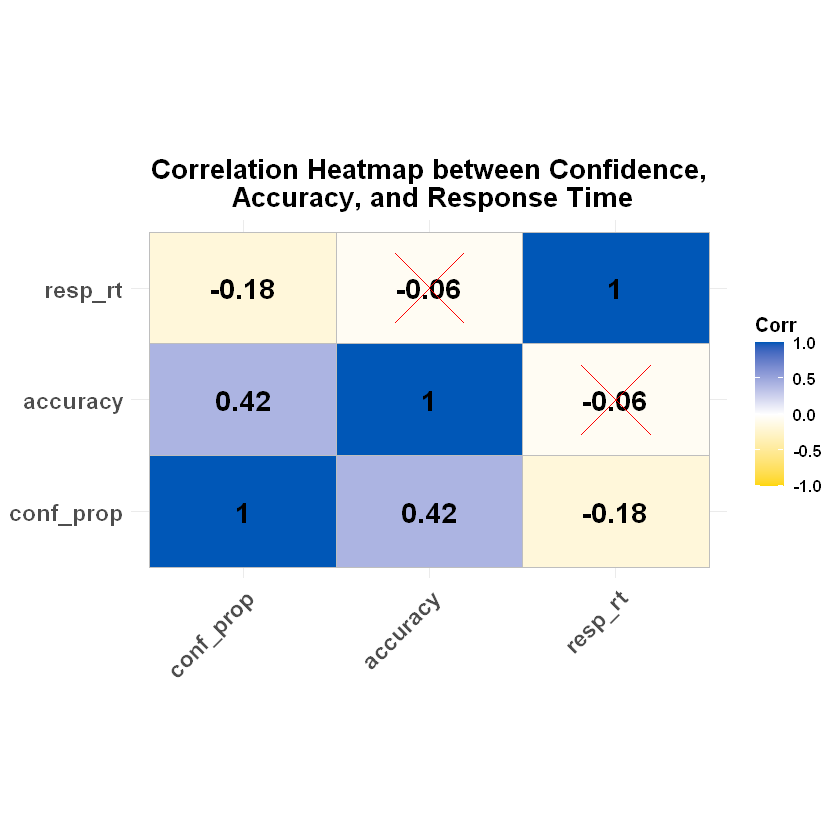

In [ ]:
cor_matrix <- cor(corr_data, method = "spearman", use = "complete.obs")
p_mat <- cor_pmat(corr_data, method = "spearman", exact = FALSE)
update_geom_defaults("text", list(fontface = "bold"))
ggcorrplot(cor_matrix,
           type = "full",
           lab = TRUE,
           lab_size = 6,
           p.mat = p_mat,
           sig.level = 0.05,
           insig = "pch",
           pch.col = "red",
           pch.cex = 19,
           title = "Correlation Heatmap between Confidence,\n Accuracy, and Response Time",
           colors = c("#FFD700", "white", "#0057B7"),
           )  +
  theme(
    aspect.ratio= 0.6,
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    axis.text.x = element_text(size = 14, face = "bold"),
    axis.text.y = element_text(size= 14, face = "bold"),
    legend.title = element_text(size = 12, face = "bold"),
    legend.text = element_text(size = 10, face = "bold")
  )

In [ ]:
# Check correlation between confidence and response time
spearman_rt_test <- cor.test(conf_res$conf_prop,
                             conf_res$resp_rt,
                             method = "spearman",
                             exact = FALSE)
print(spearman_rt_test)


	Spearman's rank correlation rho

data:  conf_res$conf_prop and conf_res$resp_rt
S = 852675, p-value = 0.0205
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.1813771 



In [ ]:
# Check correlation between accuracy and response time
spearman_acc_test <- cor.test(conf_res$accuracy,
                             conf_res$resp_rt,
                             method = "spearman",
                             exact = FALSE)
print(spearman_acc_test)


	Spearman's rank correlation rho

data:  conf_res$accuracy and conf_res$resp_rt
S = 765643, p-value = 0.4408
alternative hypothesis: true rho is not equal to 0
sample estimates:
        rho 
-0.06079384 



In [ ]:
# conf prop and response time
spearman_acc_test <- cor.test(conf_res$conf_prop,
                             conf_res$accuracy,
                             method = "spearman",
                             exact = FALSE)
print(spearman_acc_test)


	Spearman's rank correlation rho

data:  conf_res$conf_prop and conf_res$accuracy
S = 422204, p-value = 3.617e-08
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.4150383 



No significant correlation between accuracy and response time.

There is a significant negative correlation between confidence proportion and the response time implying that the more confident the subject is, the lesser is the reaction time, which is expected. Less confident individuals take more time to respond during the recognition task.

### Effect of EM vs BB frames on confidence

In [ ]:
head(conf_res, 2)

,subject,conf_prop,accuracy,EM_conf_prop,BB_conf_prop,EM_accuracy,BB_accuracy,resp_rt,group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,sub100_AB_recognitionstage_2026-01-30_18h21.40.318.csv,0.80,0.975,0.9,0.7,0.95,1.00,9.48288,Abrupt
2,sub101_AB_recognitionstage_2026-01-30_19h01.11.471.csv,0.75,0.825,0.8,0.7,1.00,0.65,6.00185,Abrupt


In [ ]:
# Compare EM vs BB confidence proportions
wilcox_frame <- wilcox.test(conf_res$EM_conf_prop,
                            conf_res$BB_conf_prop,
                            paired = TRUE,
                            exact = FALSE)

print(wilcox_frame)


	Wilcoxon signed rank test with continuity correction

data:  conf_res$EM_conf_prop and conf_res$BB_conf_prop
V = 5333, p-value = 0.01213
alternative hypothesis: true location shift is not equal to 0



In [ ]:
# Checking directionality using a one-tailed test
wilcox_conf_one_tailed <- wilcox.test(conf_res$EM_conf_prop,
                                     conf_res$BB_conf_prop,
                                     paired = TRUE,
                                     exact = FALSE,
                                     alternative = "greater")
print(wilcox_conf_one_tailed)


	Wilcoxon signed rank test with continuity correction

data:  conf_res$EM_conf_prop and conf_res$BB_conf_prop
V = 5333, p-value = 0.006065
alternative hypothesis: true location shift is greater than 0



In [ ]:
# Compare Natural vs Abrupt groups on overall confidence
wilcox_group <- wilcox.test(conf_prop ~ group,
                            data = conf_res,
                            exact = FALSE)

print(wilcox_group)


	Wilcoxon rank sum test with continuity correction

data:  conf_prop by group
W = 2826, p-value = 0.1067
alternative hypothesis: true location shift is not equal to 0



In [ ]:
dim(conf_res)

[1] 163   9

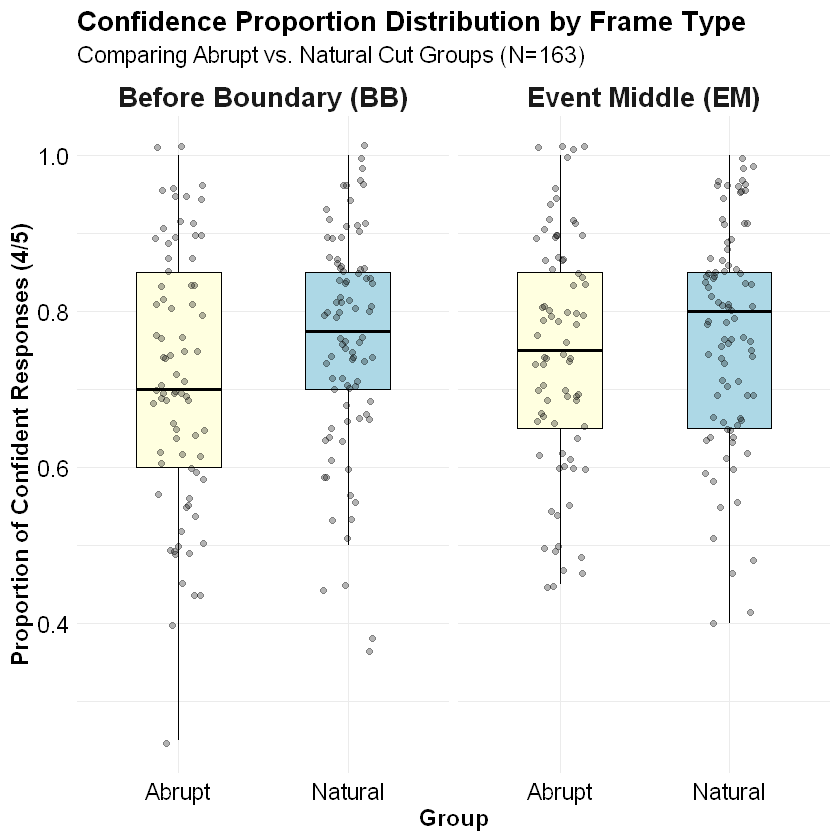

In [ ]:
# Visualize confidence proportions for EM and BB frames across the two groups
conf_res_long <- conf_res %>%
  pivot_longer(cols = c(EM_conf_prop, BB_conf_prop),
               names_to = "Frame_Type",
               values_to = "Conf_Prop") %>%
  mutate(Frame_Type = recode(Frame_Type,
                             "EM_conf_prop" = "Event Middle (EM)",
                             "BB_conf_prop" = "Before Boundary (BB)"))

ggplot(conf_res_long, aes(x = group, y = Conf_Prop, fill = group)) +
  geom_boxplot(width = 0.5, color = "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  facet_wrap(~Frame_Type) +
  theme_minimal() +
  labs(title = "Confidence Proportion Distribution by Frame Type",
       subtitle = "Comparing Abrupt vs. Natural Cut Groups (N=163)",
       y = "Proportion of Confident Responses (4/5)",
       x = "Group") +
  scale_fill_manual(values = c("Abrupt" = "lightyellow", "Natural" = "lightblue")) +
  theme(legend.position = "none",
  text = element_text(face = "bold", size = 16),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 14, face = "plain"),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 14, face = "plain", color = "black"),
    strip.text = element_text(size = 16, face = "bold"))

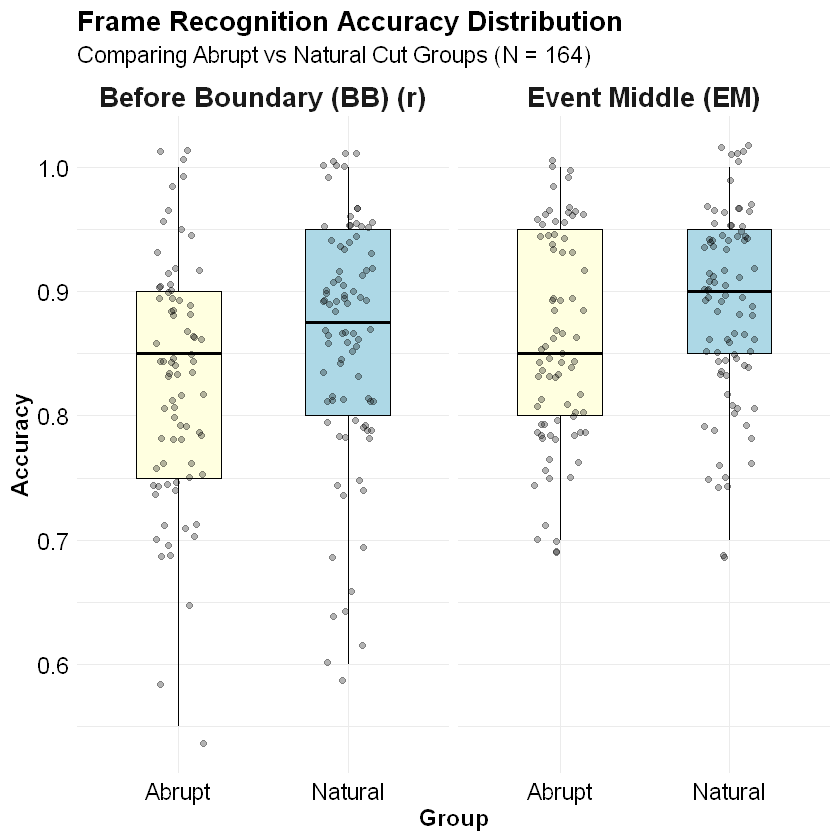

In [ ]:
# Visualize accuracy for EM and BB frames across the two groups
df_long_plot <- conf_res %>%
  select(subject, group, EM_accuracy, BB_accuracy) %>%
  pivot_longer(
    cols = c(EM_accuracy, BB_accuracy),
    names_to = "frame_type",
    values_to = "accuracy"
  ) %>%
  mutate(frame_type = recode(frame_type,
                             EM_accuracy = "Event Middle (EM)",
                            BB_accuracy = "Before Boundary (BB) (r)"))

ggplot(df_long_plot, aes(x = group, y = accuracy, fill = group)) +
  geom_boxplot(width = 0.5, color= "black", outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.3) +
  facet_wrap(~frame_type) +
  scale_fill_manual(values = c("Abrupt" = "lightyellow",
                               "Natural" = "lightblue")) +
  labs(
    title = "Frame Recognition Accuracy Distribution",
    subtitle = "Comparing Abrupt vs Natural Cut Groups (N = 164)",
    x = "Group",
    y = "Accuracy"
  ) +
  theme_minimal() +
    theme(legend.position = "none",
    text = element_text(face = "bold", size = 16),
    plot.title = element_text(size = 16, face = "bold"),
    plot.subtitle = element_text(size = 14, face = "plain"),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 14, face = "plain", color = "black"),
    strip.text = element_text(size = 16, face = "bold"))

In [ ]:
# add response time to df_long_plot
df_long_plot <- df_long_plot %>%
  left_join(conf_res %>% select(subject, resp_rt), by = "subject")

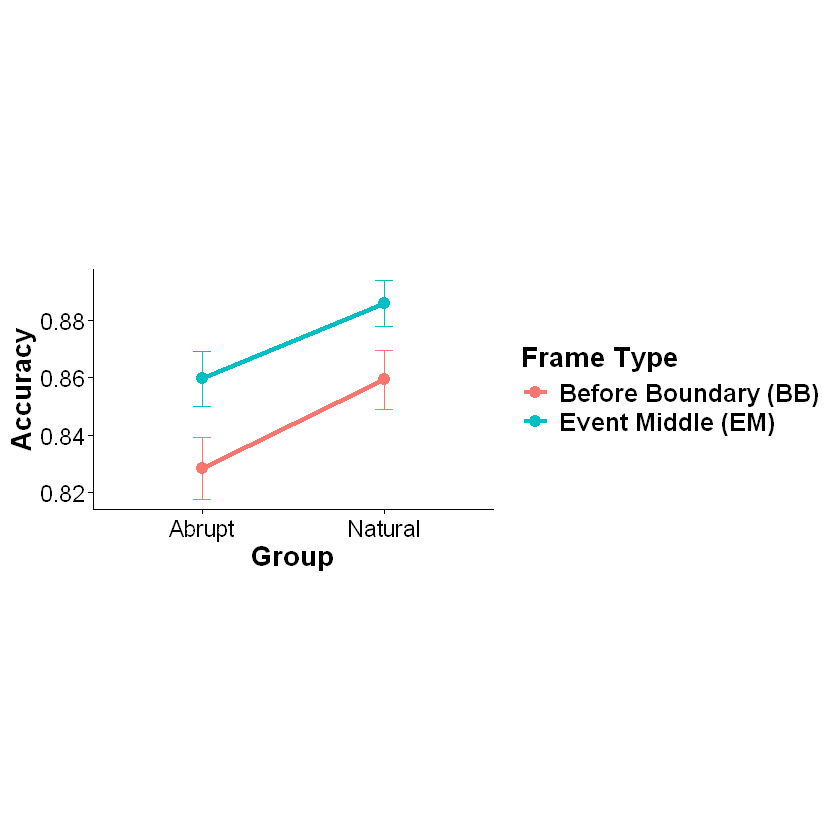

In [ ]:
# interaction line plot to check for interaction between group and frame type on accuracy
ggplot(df_long_plot, aes(x = group, y = accuracy, color = frame_type, group = frame_type)) +
  stat_summary(fun = mean, geom = "line", linewidth = 1.2) +
  stat_summary(fun = mean, geom = "point", size = 3) +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.1) +
  labs(
    x = "Group",
    y = "Accuracy",
    color = "Frame Type"
  ) +
  theme_classic()+
  theme(
    aspect.ratio = 0.6,
    text = element_text(face = "bold", size = 16),
    plot.title = element_text(size = 16, face = "bold"),
    axis.title = element_text(size = 16, face = "bold"),
    axis.text = element_text(size = 14, face = "plain", color = "black"),
    legend.title = element_text(size = 16, face = "bold"),
    legend.text = element_text(size = 15, face = "bold")
  )

In [ ]:
# BH correction for multiple comparisons (AB vs NB) (two-tailed))
# test_res : RT (AB vs NB),
# welch_result : d' (EM vs BB),
# wilcox_group : confidence proportion (AB vs NB),
# BB_wilcox_res : BB accuracy (AB vs NB),
# EM_wilcox_res : EM accuracy (AB vs NB),
# acc_wilcox_res : overall accuracy (AB vs NB)
# wilcox_frame : confidence proportion (EM vs BB),
# wilcox_result : accuracy (EM vs BB)
p_values <- c(test_res$p.value, welch_result$p.value, wilcox_group$p.value, BB_wilcox_res$p.value, EM_wilcox_res$p.value, acc_wilcox_res$p.value,
wilcox_frame$p.value, wilcox_result$p.value)
adjusted_p_values <- p.adjust(p_values, method = "BH")
adjusted_p_values

[1] 0.193954214 0.009812288 0.121905740 0.040187330 0.040187330 0.030682104
[7] 0.030682104 0.009812288

In [ ]:
# adjusted p values for one tailed tests
# acc_wilcox_res_onetailed : overall accuracy (AB vs NB),
# one_tailed_result: d' (AB vs NB),
# EM_wilcox_res_onetailed : EM accuracy (AB vs NB),
# BB_wilcox_res_onetailed : BB accuracy (AB vs NB),
# wilcox_result_one_tailed : accuracy (EM vs BB),
# wilcox_conf_one_tailed : confidence proportion (EM vs BB)
p_values_one_tailed <- c(acc_wilcox_res_onetailed$p.value, one_tailed_result$p.value, BB_wilcox_res_onetailed$p.value,
 EM_wilcox_res_onetailed$p.value, wilcox_result_one_tailed$p.value, wilcox_conf_one_tailed$p.value)
adjusted_p_values_one_tailed <- p.adjust(p_values_one_tailed, method = "BH")
adjusted_p_values_one_tailed

[1] 0.011505789 0.003679608 0.015070249 0.015070249 0.003679608 0.011505789